In [1]:
# ======================================================
# CLASS IMBALANCE & TIME-BASED SPLIT CHECK
# ======================================================

import pandas as pd
from pathlib import Path
from datetime import datetime

DATA_CLEAN = Path("data clean")
TRAIN_PATH = DATA_CLEAN / "train_features_2017_2025_lagged.csv"

# ---------- Load ----------
df = pd.read_csv(TRAIN_PATH)
label_col = "phase3plus_binary_20pct"

if label_col not in df.columns:
    raise ValueError(f"Label column '{label_col}' not found in dataset.")

df["year_month"] = pd.to_datetime(df["year_month"], format="%Y-%m", errors="coerce")

print("=" * 70)
print("CLASS DISTRIBUTION BY COUNTRY")
print("=" * 70)

# ---------- Overall imbalance ----------
overall = df[label_col].value_counts(normalize=True)
print("\nOverall distribution:")
for cls, pct in overall.items():
    print(f"  Class {cls}: {pct:.2%}")

# ---------- Country-level imbalance ----------
for country in sorted(df["country"].unique()):
    sub = df[df["country"] == country][label_col]
    dist = sub.value_counts(normalize=True)
    imbalance_ratio = dist.max() / dist.min() if len(dist) > 1 else float("inf")
    print(f"\n{country}: {len(sub):,} samples | Phase3+ {dist.get(1, 0):.2%} | Ratio {imbalance_ratio:.1f}:1")

print("\nInterpretation: Severe imbalance (>20:1) indicates class weighting may be required.")

# ======================================================
# TIME-BASED TRAIN / TEST SPLIT (80 / 20)
# ======================================================

# Sort by time to ensure temporal order
df = df.sort_values(["country", "admin1_key", "year_month"]).reset_index(drop=True)

# Determine cutoff date (80% quantile)
split_date = df["year_month"].quantile(0.8)
train = df[df["year_month"] <= split_date]
test = df[df["year_month"] > split_date]

print("\nTime-based split summary:")
print(f"  Split date: {split_date.strftime('%Y-%m')}")
print(f"  Train: {len(train):,} rows  ({len(train)/len(df):.1%})")
print(f"  Test : {len(test):,} rows  ({len(test)/len(df):.1%})")

# Save subsets
train_path = DATA_CLEAN / "train_split_80.csv"
test_path  = DATA_CLEAN / "test_split_20.csv"
train.to_csv(train_path, index=False, encoding="utf-8-sig")
test.to_csv(test_path, index=False, encoding="utf-8-sig")

print(f"\nSaved: {train_path}")
print(f"Saved: {test_path}")


CLASS DISTRIBUTION BY COUNTRY

Overall distribution:
  Class 1: 90.08%
  Class 0: 9.92%

CAF: 3,045 samples | Phase3+ 100.00% | Ratio inf:1

MDG: 420 samples | Phase3+ 72.86% | Ratio 2.7:1

MOZ: 1,155 samples | Phase3+ 63.46% | Ratio 1.7:1

SOM: 1,890 samples | Phase3+ 86.98% | Ratio 6.7:1

SSD: 1,470 samples | Phase3+ 99.32% | Ratio 146.0:1

Interpretation: Severe imbalance (>20:1) indicates class weighting may be required.

Time-based split summary:
  Split date: 2023-12
  Train: 6,384 rows  (80.0%)
  Test : 1,596 rows  (20.0%)

Saved: data clean\train_split_80.csv
Saved: data clean\test_split_20.csv


In [2]:
# ======================================================
# baseline_persistence.py
# ======================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

# ===== Paths =====
DATA_CLEAN = Path("data clean")
TRAIN_PATH = DATA_CLEAN / "train_features_2017_2025_lagged.csv"
OUT_PATH   = DATA_CLEAN / "baseline_persistence_results.csv"

# ===== 1. Load data =====
if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"File not found: {TRAIN_PATH}")

df = pd.read_csv(TRAIN_PATH)
print(f"Loaded: {TRAIN_PATH.name}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# ===== 2. Prepare evaluation dataset =====
eval_cols = [
    "country", "admin1", "admin1_key", "year_month",
    "phase3plus_binary_20pct",
    "phase3plus_binary_20pct_h1",
    "phase3plus_binary_20pct_h3"
]
df_eval = df[eval_cols].dropna().copy()
print(f"After dropping NAs: {df_eval.shape[0]:,} rows\n")

# ===== 3. Persistence and Random baselines =====
df_eval["pred_h1_persistence"] = df_eval["phase3plus_binary_20pct"]
df_eval["pred_h3_persistence"] = df_eval["phase3plus_binary_20pct"]

p_positive = df_eval["phase3plus_binary_20pct"].mean()
np.random.seed(42)
df_eval["pred_h1_random"] = np.random.binomial(1, p_positive, size=len(df_eval))
df_eval["pred_h3_random"] = np.random.binomial(1, p_positive, size=len(df_eval))

# ===== 4. Metric computation =====
def eval_metrics(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    return {
        "label": label,
        "accuracy": round(acc, 4),
        "precision": round(prec, 4),
        "recall": round(rec, 4),
        "f1_score": round(f1, 4),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn)
    }

# ===== 5. Overall evaluation =====
results = []
results.append(eval_metrics(df_eval["phase3plus_binary_20pct_h1"], df_eval["pred_h1_persistence"], "h1_Persistence"))
results.append(eval_metrics(df_eval["phase3plus_binary_20pct_h1"], df_eval["pred_h1_random"], "h1_Random"))
results.append(eval_metrics(df_eval["phase3plus_binary_20pct_h3"], df_eval["pred_h3_persistence"], "h3_Persistence"))
results.append(eval_metrics(df_eval["phase3plus_binary_20pct_h3"], df_eval["pred_h3_random"], "h3_Random"))
overall = pd.DataFrame(results)

print("=" * 70)
print("OVERALL BASELINE PERFORMANCE")
print("=" * 70)
print(overall.to_string(index=False))
print()

# ===== 6. Country-level evaluation =====
country_results = []
for country in sorted(df_eval["country"].unique()):
    sub = df_eval[df_eval["country"] == country]
    country_results.extend([
        eval_metrics(sub["phase3plus_binary_20pct_h1"], sub["pred_h1_persistence"], f"{country}_h1_Persistence"),
        eval_metrics(sub["phase3plus_binary_20pct_h1"], sub["pred_h1_random"], f"{country}_h1_Random"),
        eval_metrics(sub["phase3plus_binary_20pct_h3"], sub["pred_h3_persistence"], f"{country}_h3_Persistence"),
        eval_metrics(sub["phase3plus_binary_20pct_h3"], sub["pred_h3_random"], f"{country}_h3_Random")
    ])

by_country = pd.DataFrame(country_results)

print("=" * 70)
print("BASELINE PERFORMANCE BY COUNTRY")
print("=" * 70)
print(by_country.to_string(index=False))
print()

# ===== 7. Export results =====
all_results = pd.concat([overall, by_country], ignore_index=True)
all_results.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print(f"Results exported: {OUT_PATH}\n")

# ===== 8. Key insights =====
h1_pers_acc = overall.loc[overall["label"] == "h1_Persistence", "accuracy"].values[0]
h3_pers_acc = overall.loc[overall["label"] == "h3_Persistence", "accuracy"].values[0]

print("=" * 70)
print("SUMMARY INTERPRETATION")
print("=" * 70)
print(f"Persistence baseline accuracy:")
print(f" - h1 (next month): {h1_pers_acc:.2%}")
print(f" - h3 (3 months ahead): {h3_pers_acc:.2%}\n")

if h1_pers_acc > 0.85:
    print("Interpretation: Food security conditions are highly persistent.")
    print("Models must outperform this strong baseline to demonstrate added value.")
else:
    print("Interpretation: Food security is volatile; machine learning models have more potential for improvement.")
print()

# ===== 9. Class imbalance note =====
pos_rate = df_eval["phase3plus_binary_20pct"].mean()
print("=" * 70)
print("CLASS IMBALANCE DIAGNOSTIC")
print("=" * 70)
print(f"Share of Phase 3+ (label=1): {pos_rate:.2%}")
print()

# ===== 10. Country-level persistence summary =====
summary = []
for country in sorted(df_eval["country"].unique()):
    sub = df_eval[df_eval["country"] == country]
    acc = accuracy_score(sub["phase3plus_binary_20pct_h1"], sub["pred_h1_persistence"])
    class_dist = sub["phase3plus_binary_20pct_h1"].value_counts(normalize=True)
    minority = class_dist.get(0.0, 0)
    flag = "Low ML Potential" if acc > 0.98 else "High ML Potential"
    summary.append({
        "Country": country,
        "Persistence_Accuracy": f"{acc:.2%}",
        "Minority_Share": f"{minority:.2%}",
        "Interpretation": flag
    })

summary_df = pd.DataFrame(summary)
print("=" * 70)
print("h1 PERSISTENCE BY COUNTRY")
print("=" * 70)
print(summary_df.to_string(index=False))
print()


Loaded: train_features_2017_2025_lagged.csv
Shape: 7,980 rows × 47 columns

After dropping NAs: 7,980 rows

OVERALL BASELINE PERFORMANCE
         label  accuracy  precision  recall  f1_score   TP  FP  TN  FN
h1_Persistence    0.9840     0.9917  0.9906    0.9911 7128  60 724  68
     h1_Random    0.8213     0.9005  0.9015    0.9010 6487 717  67 709
h3_Persistence    0.9566     0.9768  0.9751    0.9760 7021 167 613 179
     h3_Random    0.8258     0.9029  0.9042    0.9035 6510 700  80 690



C:\Users\migo8\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
C:\Users\migo8\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


BASELINE PERFORMANCE BY COUNTRY
             label  accuracy  precision  recall  f1_score   TP  FP  TN  FN
CAF_h1_Persistence    1.0000     1.0000  1.0000    1.0000    0   0   0   0
     CAF_h1_Random    0.9025     1.0000  0.9025    0.9487 2748   0   0 297
CAF_h3_Persistence    1.0000     1.0000  1.0000    1.0000    0   0   0   0
     CAF_h3_Random    0.9077     1.0000  0.9077    0.9516 2764   0   0 281
MDG_h1_Persistence    0.9929     0.9935  0.9967    0.9951  304   2 113   1
     MDG_h1_Random    0.6762     0.7183  0.9115    0.8035  278 109   6  27
MDG_h3_Persistence    0.9786     0.9804  0.9901    0.9852  300   6 111   3
     MDG_h3_Random    0.6690     0.7193  0.8878    0.7947  269 105  12  34
MOZ_h1_Persistence    0.9602     0.9700  0.9673    0.9687  711  22 398  24
     MOZ_h1_Random    0.6061     0.6331  0.9061    0.7454  666 386  34  69
MOZ_h3_Persistence    0.8805     0.9100  0.9026    0.9062  667  66 350  72
     MOZ_h3_Random    0.6087     0.6392  0.8917    0.7446  659 372  

In [3]:
# ======================================================
# train_logistic_regression_CV.py
# ======================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

# ======================================================
# Global configuration
# ======================================================
DATA_CLEAN = Path("data clean")
TRAIN_PATH = DATA_CLEAN / "train_features_2017_2025_lagged.csv"
OUT_DIR = DATA_CLEAN / "model_results"
OUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TRAIN_RATIO = 0.8  # 80% for training+validation (CV), 20% for final test


# ======================================================
# Evaluation metrics
# ======================================================
def comprehensive_eval(y_true, y_pred, y_pred_proba):
    """Compute detailed metrics for imbalanced binary classification."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_pred_proba) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": average_precision_score(y_true, y_pred_proba) if len(np.unique(y_true)) > 1 else None,
        "precision_minority": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_minority": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_minority": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision_majority": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_majority": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_majority": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


# ======================================================
# Main function: train and evaluate Logistic Regression
# ======================================================
def run_for_horizon(TARGET_HORIZON):

    print("\n" + "-" * 40)
    print(f"LOGISTIC REGRESSION (TimeSeriesSplit CV) — HORIZON = {TARGET_HORIZON}")
    print("-" * 40)

    # ===== 1. Load and prepare =====
    df = pd.read_csv(TRAIN_PATH)
    for col in ["phase3plus_binary_20pct", "phase3plus_binary_20pct_h1", "phase3plus_binary_20pct_h3"]:
        if col in df.columns:
            df[col] = df[col].astype(float)
    df["year_month"] = pd.to_datetime(df["year_month"])

    target_col = f"phase3plus_binary_20pct_{TARGET_HORIZON}"
    print(f"Target variable: {target_col}")

    # ===== 2. Feature selection =====
    id_cols = ["country", "admin1", "admin1_key", "year_month"]
    exclude_cols = id_cols + ["phase3plus_binary_20pct_h1", "phase3plus_binary_20pct_h3"]
    feature_cols = [c for c in df.columns if c not in exclude_cols]

    # remove baseline leakage
    feature_cols = [c for c in feature_cols if c != "phase3plus_binary_20pct"]

    df_model = df[feature_cols + [target_col, "country", "year_month"]].dropna(subset=[target_col])
    print(f"Samples with valid target: {len(df_model):,}")
    print(f"Feature count: {len(feature_cols)}")

    # ===== 3. Filter usable countries =====
    country_stats = []
    for country in sorted(df_model["country"].unique()):
        sub = df_model[df_model["country"] == country]
        dist = sub[target_col].value_counts(normalize=True)
        pct0 = dist.get(0.0, 0.0)
        country_stats.append({"country": country, "class_0_pct": pct0, "n": len(sub)})

    trainable_countries = [c["country"] for c in country_stats if 0.01 < c["class_0_pct"] < 0.99]
    df_train_data = df_model[df_model["country"].isin(trainable_countries)].sort_values("year_month").reset_index(drop=True)

    print(f"Trainable countries: {trainable_countries}")
    print(f"Total usable samples: {len(df_train_data):,}")

    # ===== 4. Time-based split (80/20) =====
    n_total = len(df_train_data)
    n_train_val = int(n_total * TRAIN_RATIO)
    train_val_data = df_train_data.iloc[:n_train_val].copy()
    test_data = df_train_data.iloc[n_train_val:].copy()
    cutoff_date = train_val_data.iloc[-1]["year_month"]

    print("\nTime-based split summary:")
    print(f"Cutoff date: {cutoff_date.strftime('%Y-%m')}")
    print(f"Train+Val: {len(train_val_data):,}")
    print(f"Test:      {len(test_data):,}")

    # ===== 5. Prepare X/y =====
    X_train_val = train_val_data[feature_cols]
    y_train_val = train_val_data[target_col].astype(float).to_numpy().ravel()
    X_test = test_data[feature_cols]
    y_test = test_data[target_col].astype(float).to_numpy().ravel()

    # ===== 6. Imputation and scaling =====
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train_val_scaled = scaler.fit_transform(imputer.fit_transform(X_train_val))
    X_test_scaled = scaler.transform(imputer.transform(X_test))

    print("\nClass distribution:")
    print("Train+Val:", pd.Series(y_train_val).value_counts(normalize=True).to_dict())
    print("Test:     ", pd.Series(y_test).value_counts(normalize=True).to_dict())

    # ===== 7. TimeSeriesSplit CV grid search =====
    print("\nPerforming 5-fold TimeSeriesSplit grid search...")

    param_grid = {
        "C": [0.01, 0.1, 1.0, 10.0],
        "penalty": ["l1","l2"],
        "solver": ["liblinear", "saga"],
        "max_iter": [2000],
    }

    tscv = TimeSeriesSplit(n_splits=5)
    best_score = -np.inf
    best_params = {}
    cv_results = []

    for params in ParameterGrid(param_grid):
        fold_scores = []
        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_val_scaled)):
            X_tr, X_val = X_train_val_scaled[tr_idx], X_train_val_scaled[val_idx]
            y_tr, y_val = y_train_val[tr_idx], y_train_val[val_idx]

            n_0, n_1 = (y_tr == 0).sum(), (y_tr == 1).sum()
            class_weight = {
                0: len(y_tr) / (2 * n_0) if n_0 > 0 else 1.0,
                1: len(y_tr) / (2 * n_1) if n_1 > 0 else 1.0,
            }

            model = LogisticRegression(**params, class_weight=class_weight, random_state=RANDOM_STATE)
            model.fit(X_tr, y_tr)

            val_proba = model.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, val_proba) if len(np.unique(y_val)) > 1 else 0.5
            fold_scores.append(score)

        mean_score = float(np.mean(fold_scores))
        std_score = float(np.std(fold_scores))
        cv_results.append({**params, "mean_auc": mean_score, "std_auc": std_score})

        if mean_score > best_score:
            best_score = mean_score
            best_params = params

    cv_df = pd.DataFrame(cv_results).sort_values("mean_auc", ascending=False)
    cv_df.to_csv(OUT_DIR / f"logreg_{TARGET_HORIZON}_cv_results.csv", index=False)

    print(f"Best params: {best_params}")
    print(f"Best mean CV ROC-AUC: {best_score:.4f}")

    # ===== 8. Train final model on full train+val =====
    n_0, n_1 = (y_train_val == 0).sum(), (y_train_val == 1).sum()
    final_class_weight = {
        0: len(y_train_val) / (2 * n_0),
        1: len(y_train_val) / (2 * n_1),
    }

    final_model = LogisticRegression(**best_params, class_weight=final_class_weight, random_state=RANDOM_STATE)
    final_model.fit(X_train_val_scaled, y_train_val)
    print("Final model trained on full train+validation set.")

    # ===== 9. Evaluate on held-out test =====
    test_pred = final_model.predict(X_test_scaled)
    test_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]
    test_metrics = comprehensive_eval(y_test, test_pred, test_pred_proba)

    print("\nTest classification report:")
    print(classification_report(y_test, test_pred, digits=4, target_names=["Phase1-2 (0)", "Phase3+ (1)"]))
    print("Confusion matrix:")
    print(pd.DataFrame(confusion_matrix(y_test, test_pred),
                       index=["Actual 0", "Actual 1"],
                       columns=["Pred 0", "Pred 1"]))
    print(f"ROC-AUC: {test_metrics['roc_auc']:.4f}")
    print(f"PR-AUC:  {test_metrics['pr_auc']:.4f}")
    print(f"Minority recall (0): {test_metrics['recall_minority']:.4f}")
    print(f"Majority recall (1): {test_metrics['recall_majority']:.4f}")

    # ===== 10. Save coefficients and results =====
    coef_df = pd.DataFrame({
        "feature": feature_cols,
        "coefficient": final_model.coef_[0]
    }).sort_values("coefficient", key=abs, ascending=False)

    results = {
        "model": "Logistic Regression (CV)",
        "horizon": TARGET_HORIZON,
        "split_method": "80/20 time split + TimeSeriesSplit (5 folds)",
        "best_params": str(best_params),
        "cv_auc": best_score,
        "n_train_val": len(y_train_val),
        "n_test": len(y_test),
        "test_accuracy": test_metrics["accuracy"],
        "test_roc_auc": test_metrics["roc_auc"],
        "test_pr_auc": test_metrics["pr_auc"],
        "minority_recall": test_metrics["recall_minority"],
        "majority_recall": test_metrics["recall_majority"],
    }

    pd.DataFrame([results]).to_csv(OUT_DIR / f"logreg_{TARGET_HORIZON}_summary.csv", index=False)
    coef_df.to_csv(OUT_DIR / f"logreg_{TARGET_HORIZON}_coefficients.csv", index=False)

    print(f"\nResults saved to {OUT_DIR}")
    return {
        "horizon": TARGET_HORIZON,
        "cv_auc": best_score,
        "test_auc": test_metrics["roc_auc"],
        "test_acc": test_metrics["accuracy"],
        "minority_recall": test_metrics["recall_minority"],
    }


# ======================================================
# Run both horizons
# ======================================================
if __name__ == "__main__":
    summary_h1 = run_for_horizon("h1")
    summary_h3 = run_for_horizon("h3")

    print("\n" + "=" * 70)
    print("SUMMARY COMPARISON (h1 vs h3)")
    print("=" * 70)
    summary_df = pd.DataFrame([summary_h1, summary_h3])
    print(summary_df.to_string(index=False))
    print(f"\nAll results are saved in: {OUT_DIR}")



----------------------------------------
LOGISTIC REGRESSION (TimeSeriesSplit CV) — HORIZON = h1
----------------------------------------
Target variable: phase3plus_binary_20pct_h1
Samples with valid target: 7,980
Feature count: 40
Trainable countries: ['MDG', 'MOZ', 'SOM']
Total usable samples: 3,465

Time-based split summary:
Cutoff date: 2023-12
Train+Val: 2,772
Test:      693

Class distribution:
Train+Val: {1.0: 0.7380952380952381, 0.0: 0.2619047619047619}
Test:      {1.0: 0.9292929292929293, 0.0: 0.0707070707070707}

Performing 5-fold TimeSeriesSplit grid search...
Best params: {'C': 0.01, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}
Best mean CV ROC-AUC: 0.9613
Final model trained on full train+validation set.

Test classification report:
              precision    recall  f1-score   support

Phase1-2 (0)     0.7143    0.9184    0.8036        49
 Phase3+ (1)     0.9937    0.9720    0.9827       644

    accuracy                         0.9683       693
   macro avg    

In [4]:
# ======================================================
# train_random_forest_CV.py
# ======================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)
import warnings
warnings.filterwarnings("ignore")

# ======================================================
# Global configuration
# ======================================================
DATA_CLEAN = Path("data clean")
TRAIN_PATH = DATA_CLEAN / "train_features_2017_2025_lagged.csv"
OUT_DIR = DATA_CLEAN / "model_results"
OUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TRAIN_RATIO = 0.8  # earliest 80% for train+val, latest 20% for test


# ======================================================
# Helper: evaluation metrics
# ======================================================
def comprehensive_eval(y_true, y_pred, y_pred_proba):
    """Compute detailed metrics for imbalanced binary classification."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_pred_proba) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": average_precision_score(y_true, y_pred_proba) if len(np.unique(y_true)) > 1 else None,
        "precision_minority": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_minority": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_minority": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision_majority": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_majority": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_majority": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


# ======================================================
# Core: Run Random Forest pipeline for one horizon
# ======================================================
def run_for_horizon(TARGET_HORIZON):

    print("\n" + "-" * 40)
    print(f"RANDOM FOREST (TimeSeriesSplit + class_weight) — HORIZON = {TARGET_HORIZON}")
    print("-" * 40)

    # ===== 1. Load data =====
    df = pd.read_csv(TRAIN_PATH)
    for col in ["phase3plus_binary_20pct", "phase3plus_binary_20pct_h1", "phase3plus_binary_20pct_h3"]:
        if col in df.columns:
            df[col] = df[col].astype(float)
    df["year_month"] = pd.to_datetime(df["year_month"])
    target_col = f"phase3plus_binary_20pct_{TARGET_HORIZON}"

    # ===== 2. Feature selection =====
    id_cols = ["country", "admin1", "admin1_key", "year_month"]
    exclude_cols = id_cols + ["phase3plus_binary_20pct_h1", "phase3plus_binary_20pct_h3"]
    feature_cols = [c for c in df.columns if c not in exclude_cols and c != "phase3plus_binary_20pct"]

    df_model = df[feature_cols + [target_col, "country", "year_month"]].dropna(subset=[target_col])
    print(f"Samples with valid target: {len(df_model):,}")
    print(f"Feature count: {len(feature_cols)}")

    # ===== 3. Keep only countries with both classes =====
    valid_countries = []
    for c in sorted(df_model["country"].unique()):
        dist = df_model.loc[df_model["country"] == c, target_col].value_counts(normalize=True)
        pct0 = dist.get(0.0, 0.0)
        if 0.01 < pct0 < 0.99:
            valid_countries.append(c)

    df_train_data = df_model[df_model["country"].isin(valid_countries)].sort_values("year_month").reset_index(drop=True)
    print(f"Trainable countries: {valid_countries}")
    print(f"Total usable samples: {len(df_train_data):,}")

    # ===== 4. Time split (80/20) =====
    n_total = len(df_train_data)
    n_train_val = int(n_total * TRAIN_RATIO)
    train_val_data = df_train_data.iloc[:n_train_val].copy()
    test_data = df_train_data.iloc[n_train_val:].copy()
    cutoff_date = train_val_data.iloc[-1]["year_month"]

    print(f"\nTime-based split: cutoff = {cutoff_date.strftime('%Y-%m')}")
    print(f"Train+Val: {len(train_val_data):,}")
    print(f"Test:      {len(test_data):,}")

    # ===== 5. Prepare features =====
    X_train_val_raw = train_val_data[feature_cols]
    y_train_val = train_val_data[target_col].astype(float).to_numpy().ravel()
    X_test_raw = test_data[feature_cols]
    y_test = test_data[target_col].astype(float).to_numpy().ravel()

    # ===== 6. Imputation =====
    imputer = SimpleImputer(strategy="median")
    X_train_val = imputer.fit_transform(X_train_val_raw)
    X_test = imputer.transform(X_test_raw)

    # ===== 7. Hyperparameter tuning (TimeSeriesSplit CV) =====
    print("\nPerforming 5-fold TimeSeriesSplit cross-validation with class_weight='balanced_subsample'...")

    param_grid = {
        "n_estimators": [200, 400],
        "max_depth": [8, 12, None],
        "min_samples_split": [5, 10, 20],
        "min_samples_leaf": [5, 10],
    }

    tscv = TimeSeriesSplit(n_splits=5)
    best_score, best_params = -np.inf, {}
    cv_results = []

    for params in ParameterGrid(param_grid):
        fold_scores = []
        for tr_idx, val_idx in tscv.split(X_train_val):
            X_tr, y_tr = X_train_val[tr_idx], y_train_val[tr_idx]
            X_val, y_val = X_train_val[val_idx], y_train_val[val_idx]

            model = RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced_subsample",
                **params
            )
            model.fit(X_tr, y_tr)

            if len(np.unique(y_val)) > 1:
                score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
            else:
                score = 0.5
            fold_scores.append(score)

        mean_auc = np.mean(fold_scores)
        std_auc = np.std(fold_scores)
        cv_results.append({**params, "mean_auc": mean_auc, "std_auc": std_auc})

        if mean_auc > best_score:
            best_score, best_params = mean_auc, params

    cv_df = pd.DataFrame(cv_results).sort_values("mean_auc", ascending=False)
    cv_df.to_csv(OUT_DIR / f"rf_{TARGET_HORIZON}_cv_results.csv", index=False)
    print(f"Best parameters: {best_params}")
    print(f"Best CV ROC-AUC: {best_score:.4f}")

    # ===== 8. Train final model =====
    final_model = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
        **best_params
    )
    final_model.fit(X_train_val, y_train_val)
    print("Final model trained on full train+validation set.")

    # ===== 9. Evaluate on held-out test =====
    test_pred = final_model.predict(X_test)
    test_proba = final_model.predict_proba(X_test)[:, 1]
    metrics = comprehensive_eval(y_test, test_pred, test_proba)

    print("\nTest classification report:")
    print(classification_report(y_test, test_pred, digits=4, target_names=["Phase1-2 (0)", "Phase3+ (1)"]))
    print("Confusion matrix:")
    print(pd.DataFrame(confusion_matrix(y_test, test_pred),
                       index=["Actual 0", "Actual 1"],
                       columns=["Pred 0", "Pred 1"]))
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"PR-AUC:  {metrics['pr_auc']:.4f}")
    print(f"Minority recall (0): {metrics['recall_minority']:.4f}")
    print(f"Majority recall (1): {metrics['recall_majority']:.4f}")

    # ===== 10. Feature importance =====
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False)
    importance_df.to_csv(OUT_DIR / f"rf_{TARGET_HORIZON}_importance.csv", index=False)

    # ===== 11. Save results =====
    results = {
        "model": "Random Forest (CV + class_weight)",
        "horizon": TARGET_HORIZON,
        "split_method": "80/20 + TimeSeriesSplit",
        "cv_auc": best_score,
        "best_params": str(best_params),
        "test_accuracy": metrics["accuracy"],
        "test_roc_auc": metrics["roc_auc"],
        "test_pr_auc": metrics["pr_auc"],
        "minority_recall": metrics["recall_minority"],
        "majority_recall": metrics["recall_majority"],
    }

    pd.DataFrame([results]).to_csv(OUT_DIR / f"rf_{TARGET_HORIZON}_summary.csv", index=False)
    print(f"\nResults saved to {OUT_DIR}")
    return results


# ======================================================
# MAIN: run both horizons
# ======================================================
if __name__ == "__main__":
    summary_h1 = run_for_horizon("h1")
    summary_h3 = run_for_horizon("h3")

    summary_df = pd.DataFrame([summary_h1, summary_h3])
    print("\n" + "=" * 70)
    print("SUMMARY ACROSS HORIZONS (Random Forest - Safe Version)")
    print("=" * 70)
    print(summary_df.to_string(index=False))
    print(f"\nAll results saved in: {OUT_DIR}")



----------------------------------------
RANDOM FOREST (TimeSeriesSplit + class_weight) — HORIZON = h1
----------------------------------------
Samples with valid target: 7,980
Feature count: 40
Trainable countries: ['MDG', 'MOZ', 'SOM']
Total usable samples: 3,465

Time-based split: cutoff = 2023-12
Train+Val: 2,772
Test:      693

Performing 5-fold TimeSeriesSplit cross-validation with class_weight='balanced_subsample'...
Best parameters: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.9590
Final model trained on full train+validation set.

Test classification report:
              precision    recall  f1-score   support

Phase1-2 (0)     0.8571    0.8571    0.8571        49
 Phase3+ (1)     0.9891    0.9891    0.9891       644

    accuracy                         0.9798       693
   macro avg     0.9231    0.9231    0.9231       693
weighted avg     0.9798    0.9798    0.9798       693

Confusion matrix:
          Pred 0  Pre

In [5]:
# ======================================================
# train_xgboost_CV.py
# ======================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)
import warnings
warnings.filterwarnings("ignore")

try:
    import xgboost as xgb
except ImportError as e:
    raise ImportError("XGBoost not installed. Please run: pip install xgboost") from e

# ======================================================
# Global configuration
# ======================================================
DATA_CLEAN = Path("data clean")
TRAIN_PATH = DATA_CLEAN / "train_features_2017_2025_lagged.csv"
OUT_DIR = DATA_CLEAN / "model_results"
OUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TRAIN_RATIO = 0.8  # earliest 80% for train+val, latest 20% for test


# ======================================================
# Helper: evaluation metrics
# ======================================================
def comprehensive_eval(y_true, y_pred, y_pred_proba):
    """Compute detailed metrics for imbalanced binary classification."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_pred_proba) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": average_precision_score(y_true, y_pred_proba) if len(np.unique(y_true)) > 1 else None,
        "precision_minority": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_minority": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_minority": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision_majority": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_majority": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_majority": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


# ======================================================
# Core: Run XGBoost pipeline for one horizon
# ======================================================
def run_for_horizon(TARGET_HORIZON):

    print("\n" + "-" * 40)
    print(f"XGBOOST (TimeSeriesSplit CV + scale_pos_weight) — HORIZON = {TARGET_HORIZON}")
    print("-" * 40)

    # ===== 1. Load data =====
    df = pd.read_csv(TRAIN_PATH)
    for col in ["phase3plus_binary_20pct", "phase3plus_binary_20pct_h1", "phase3plus_binary_20pct_h3"]:
        if col in df.columns:
            df[col] = df[col].astype(float)
    df["year_month"] = pd.to_datetime(df["year_month"])
    target_col = f"phase3plus_binary_20pct_{TARGET_HORIZON}"

    # ===== 2. Feature selection =====
    id_cols = ["country", "admin1", "admin1_key", "year_month"]
    exclude_cols = id_cols + ["phase3plus_binary_20pct_h1", "phase3plus_binary_20pct_h3"]
    feature_cols = [c for c in df.columns if c not in exclude_cols and c != "phase3plus_binary_20pct"]

    df_model = df[feature_cols + [target_col, "country", "year_month"]].dropna(subset=[target_col])
    print(f"Samples with valid target: {len(df_model):,}")
    print(f"Feature count: {len(feature_cols)}")

    # ===== 3. Keep only countries with both classes =====
    valid_countries = []
    for c in sorted(df_model["country"].unique()):
        dist = df_model.loc[df_model["country"] == c, target_col].value_counts(normalize=True)
        pct0 = dist.get(0.0, 0.0)
        if 0.01 < pct0 < 0.99:
            valid_countries.append(c)

    df_train_data = df_model[df_model["country"].isin(valid_countries)].sort_values("year_month").reset_index(drop=True)
    print(f"Trainable countries: {valid_countries}")
    print(f"Total usable samples: {len(df_train_data):,}")

    # ===== 4. Time-based split (80/20) =====
    n_total = len(df_train_data)
    n_train_val = int(n_total * TRAIN_RATIO)
    train_val_data = df_train_data.iloc[:n_train_val].copy()
    test_data = df_train_data.iloc[n_train_val:].copy()
    cutoff_date = train_val_data.iloc[-1]["year_month"]

    print(f"\nTime-based split: cutoff = {cutoff_date.strftime('%Y-%m')}")
    print(f"Train+Val: {len(train_val_data):,}")
    print(f"Test:      {len(test_data):,}")

    # ===== 5. Prepare features =====
    X_train_val_raw = train_val_data[feature_cols]
    y_train_val = train_val_data[target_col].astype(float).to_numpy().ravel()
    X_test_raw = test_data[feature_cols]
    y_test = test_data[target_col].astype(float).to_numpy().ravel()

    # ===== 6. Impute missing values =====
    imputer = SimpleImputer(strategy="median")
    X_train_val = imputer.fit_transform(X_train_val_raw)
    X_test = imputer.transform(X_test_raw)

    # ===== 7. Hyperparameter tuning with TimeSeriesSplit =====
    print("\nPerforming 5-fold TimeSeriesSplit CV with scale_pos_weight...")

    param_grid = {
        "n_estimators": [300, 400],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.7, 0.8],
        "colsample_bytree": [0.7, 0.8],
    }

    tscv = TimeSeriesSplit(n_splits=5)
    best_score, best_params = -np.inf, {}
    cv_results = []

    for params in ParameterGrid(param_grid):
        fold_scores = []
        for tr_idx, val_idx in tscv.split(X_train_val):
            X_tr, y_tr = X_train_val[tr_idx], y_train_val[tr_idx]
            X_val, y_val = X_train_val[val_idx], y_train_val[val_idx]

            n_neg = (y_tr == 0).sum()
            n_pos = (y_tr == 1).sum()
            spw = (n_neg / n_pos) if n_pos > 0 else 1.0

            model = xgb.XGBClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                eval_metric="auc",
                use_label_encoder=False,
                scale_pos_weight=spw,
                early_stopping_rounds=30,
                **params
            )
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

            if len(np.unique(y_val)) > 1:
                val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
            else:
                val_auc = 0.5
            fold_scores.append(val_auc)

        mean_auc = np.mean(fold_scores)
        std_auc = np.std(fold_scores)
        cv_results.append({**params, "mean_auc": mean_auc, "std_auc": std_auc})

        if mean_auc > best_score:
            best_score, best_params = mean_auc, params

    cv_df = pd.DataFrame(cv_results).sort_values("mean_auc", ascending=False)
    cv_df.to_csv(OUT_DIR / f"xgb_{TARGET_HORIZON}_cv_results.csv", index=False)
    print(f"Best parameters: {best_params}")
    print(f"Best CV ROC-AUC: {best_score:.4f}")

    # ===== 8. Train final model (CORRECTED VERSION) =====
    
    n_neg_full = (y_train_val == 0).sum()
    n_pos_full = (y_train_val == 1).sum()
    spw_full = (n_neg_full / n_pos_full) if n_pos_full > 0 else 1.0
    print(f"Final scale_pos_weight: {spw_full:.2f}")
    
    # Split train_val into train (90%) and validation (10%) for early stopping
    # Use shuffle=False to maintain temporal order
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=0.1,
        shuffle=False,  # ← Critical: preserve time order
        random_state=RANDOM_STATE
    )
    
    print(f"Final training: {len(X_tr):,} samples")
    print(f"Early stopping validation: {len(X_val):,} samples")
    
    # Recalculate scale_pos_weight for the 90% training subset
    n_neg_tr = (y_tr == 0).sum()
    n_pos_tr = (y_tr == 1).sum()
    spw_tr = (n_neg_tr / n_pos_tr) if n_pos_tr > 0 else 1.0
    
    final_model = xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="auc",
        use_label_encoder=False,
        scale_pos_weight=spw_tr,  # ← Use scale_pos_weight for 90% subset
        early_stopping_rounds=30,
        **best_params
    )
    
    # Fit with proper validation set for early stopping
    final_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],  # ← Now using independent 10% validation
        verbose=False
    )
    
    print(f"Best iteration: {final_model.best_iteration}")
    print(f"Best validation AUC: {final_model.best_score:.4f}")

    # ===== 9. Evaluate on held-out test =====
    test_pred = final_model.predict(X_test)
    test_proba = final_model.predict_proba(X_test)[:, 1]
    metrics = comprehensive_eval(y_test, test_pred, test_proba)

    print("\nTest classification report:")
    print(classification_report(y_test, test_pred, digits=4, target_names=["Phase1-2 (0)", "Phase3+ (1)"]))
    print("Confusion matrix:")
    print(pd.DataFrame(confusion_matrix(y_test, test_pred),
                       index=["Actual 0", "Actual 1"],
                       columns=["Pred 0", "Pred 1"]))
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"PR-AUC:  {metrics['pr_auc']:.4f}")
    print(f"Minority recall (0): {metrics['recall_minority']:.4f}")
    print(f"Majority recall (1): {metrics['recall_majority']:.4f}")

    # ===== 10. Feature importance =====
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False)
    importance_df.to_csv(OUT_DIR / f"xgb_{TARGET_HORIZON}_importance.csv", index=False)

    # ===== 11. Save results =====
    results = {
        "model": "XGBoost (CV + scale_pos_weight)",
        "horizon": TARGET_HORIZON,
        "split_method": "80/20 + TimeSeriesSplit",
        "cv_auc": best_score,
        "best_params": str(best_params),
        "test_accuracy": metrics["accuracy"],
        "test_roc_auc": metrics["roc_auc"],
        "test_pr_auc": metrics["pr_auc"],
        "minority_recall": metrics["recall_minority"],
        "majority_recall": metrics["recall_majority"],
    }

    pd.DataFrame([results]).to_csv(OUT_DIR / f"xgb_{TARGET_HORIZON}_summary.csv", index=False)
    print(f"Results saved to {OUT_DIR}")

    return results


# ======================================================
# MAIN: run both horizons and summarize
# ======================================================
if __name__ == "__main__":
    summary_h1 = run_for_horizon("h1")
    summary_h3 = run_for_horizon("h3")

    summary_df = pd.DataFrame([summary_h1, summary_h3])
    print("\n" + "=" * 70)
    print("SUMMARY ACROSS HORIZONS (XGBoost - Safe Version)")
    print("=" * 70)
    print(summary_df.to_string(index=False))
    print(f"\nAll results saved in: {OUT_DIR}")



----------------------------------------
XGBOOST (TimeSeriesSplit CV + scale_pos_weight) — HORIZON = h1
----------------------------------------
Samples with valid target: 7,980
Feature count: 40
Trainable countries: ['MDG', 'MOZ', 'SOM']
Total usable samples: 3,465

Time-based split: cutoff = 2023-12
Train+Val: 2,772
Test:      693

Performing 5-fold TimeSeriesSplit CV with scale_pos_weight...
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.7}
Best CV ROC-AUC: 0.9664
Final scale_pos_weight: 0.35
Final training: 2,494 samples
Early stopping validation: 278 samples
Best iteration: 7
Best validation AUC: 0.9928

Test classification report:
              precision    recall  f1-score   support

Phase1-2 (0)     0.7544    0.8776    0.8113        49
 Phase3+ (1)     0.9906    0.9783    0.9844       644

    accuracy                         0.9711       693
   macro avg     0.8725    0.9279    0.8978       693
weighted avg

In [6]:
# ======================================================
# baseline_persistence_safe.py
# ======================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# ======================================================
# Configuration
# ======================================================
DATA_CLEAN = Path("data clean")
TRAIN_PATH = DATA_CLEAN / "train_features_2017_2025_lagged.csv"
OUT_PATH = DATA_CLEAN / "baseline_persistence_results.csv"

# The same countries used in ML (identified from model training step)
TRAINABLE_COUNTRIES = ["MDG", "MOZ", "SOM"]
TRAIN_RATIO = 0.8  # Same as ML models


# ======================================================
# Load data and split
# ======================================================
df = pd.read_csv(TRAIN_PATH)

# Convert to datetime and sort by time
df["year_month"] = pd.to_datetime(df["year_month"])
df = df.sort_values("year_month").reset_index(drop=True)

# Apply 80/20 time-based split (same as ML models)
n_total = len(df)
n_train = int(n_total * TRAIN_RATIO)
train_data = df.iloc[:n_train].copy()
test_data = df.iloc[n_train:].copy()

print(f"Loaded: {TRAIN_PATH.name}")
print(f"Total rows: {len(df):,}")
print(f"Train set: {len(train_data):,} rows ({len(train_data)/len(df):.1%})")
print(f"Test set:  {len(test_data):,} rows ({len(test_data)/len(df):.1%})")
print(f"Train time range: {train_data['year_month'].min()} ~ {train_data['year_month'].max()}")
print(f"Test time range:  {test_data['year_month'].min()} ~ {test_data['year_month'].max()}")

# ======================================================
# Prepare evaluation data (TEST SET ONLY)
# ======================================================
eval_cols = [
    "country", "admin1", "admin1_key", "year_month",
    "phase3plus_binary_20pct",
    "phase3plus_binary_20pct_h1",
    "phase3plus_binary_20pct_h3"
]

# Use only test set for evaluation
df_test = test_data[eval_cols].dropna().copy()
print(f"\nTest set after dropping NAs: {len(df_test):,} rows")

# Restrict to trainable subset (same as ML models)
df_trainable_test = df_test[df_test["country"].isin(TRAINABLE_COUNTRIES)].copy()
print(f"Trainable countries in test set: {len(df_trainable_test):,} rows")
print(f"Countries: {TRAINABLE_COUNTRIES}\n")


# ======================================================
# Helper: compute metrics
# ======================================================
def eval_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    return acc, prec, rec, f1, tn, fp, fn, tp


# ======================================================
# Evaluate persistence rule
# ======================================================
def evaluate_persistence(df_subset, label):
    """
    Persistence rule: predict t+1 and t+3 using current value (t)
    """
    y_h1_true = df_subset["phase3plus_binary_20pct_h1"]
    y_h3_true = df_subset["phase3plus_binary_20pct_h3"]
    y_pred = df_subset["phase3plus_binary_20pct"]  # Current value

    h1_acc, h1_prec, h1_rec, h1_f1, _, _, _, _ = eval_metrics(y_h1_true, y_pred)
    h3_acc, h3_prec, h3_rec, h3_f1, _, _, _, _ = eval_metrics(y_h3_true, y_pred)

    results = pd.DataFrame([
        {"dataset": label, "horizon": "h1", "accuracy": h1_acc, "precision": h1_prec, "recall": h1_rec, "f1": h1_f1},
        {"dataset": label, "horizon": "h3", "accuracy": h3_acc, "precision": h3_prec, "recall": h3_rec, "f1": h3_f1},
    ])
    return results


# ======================================================
# Run evaluation (TEST SET ONLY)
# ======================================================
print("=" * 70)
print("EVALUATING PERSISTENCE BASELINE (TEST SET ONLY)")
print("=" * 70)

results_all_test = evaluate_persistence(df_test, "All_Countries_Test")
results_trainable_test = evaluate_persistence(df_trainable_test, "Trainable_Countries_Test")

df_results = pd.concat([results_all_test, results_trainable_test], ignore_index=True)
df_results.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")

print("\nBaseline results (TEST SET):")
print(df_results.to_string(index=False))
print(f"\nResults exported to: {OUT_PATH}")


# ======================================================
# Interpretation
# ======================================================
h1_all = df_results.query("dataset=='All_Countries_Test' & horizon=='h1'")["accuracy"].values[0]
h1_train = df_results.query("dataset=='Trainable_Countries_Test' & horizon=='h1'")["accuracy"].values[0]

print("\n" + "=" * 70)
print("INTERPRETATION SUMMARY")
print("=" * 70)
print(f"h1 persistence accuracy (1-month-ahead) on TEST SET:")
print(f"  • All countries:       {h1_all:.2%}")
print(f"  • Trainable subset:    {h1_train:.2%}")


Loaded: train_features_2017_2025_lagged.csv
Total rows: 7,980
Train set: 6,384 rows (80.0%)
Test set:  1,596 rows (20.0%)
Train time range: 2017-01-01 00:00:00 ~ 2023-12-01 00:00:00
Test time range:  2024-01-01 00:00:00 ~ 2025-09-01 00:00:00

Test set after dropping NAs: 1,596 rows
Trainable countries in test set: 693 rows
Countries: ['MDG', 'MOZ', 'SOM']

EVALUATING PERSISTENCE BASELINE (TEST SET ONLY)

Baseline results (TEST SET):
                 dataset horizon  accuracy  precision   recall       f1
      All_Countries_Test      h1  0.993108   0.996124 0.996768 0.996446
      All_Countries_Test      h3  0.979323   0.988372 0.990291 0.989331
Trainable_Countries_Test      h1  0.984127   0.990698 0.992236 0.991466
Trainable_Countries_Test      h3  0.952381   0.972093 0.976636 0.974359

Results exported to: data clean\baseline_persistence_results.csv

INTERPRETATION SUMMARY
h1 persistence accuracy (1-month-ahead) on TEST SET:
  • All countries:       99.31%
  • Trainable subset:    98.


Combined evaluation results:


,model,horizon,accuracy,roc_auc,pr_auc,minority_recall
0,Logistic Regression,h1,0.968254,0.960325,0.995269,0.918367
1,Logistic Regression,h3,0.913420,0.886843,0.987057,0.764706
2,Persistence Baseline,h1,0.984127,NaN,NaN,NaN
3,Persistence Baseline,h3,0.952381,NaN,NaN,NaN
4,Random Forest,h1,0.979798,0.942610,0.992677,0.857143
5,Random Forest,h3,0.953824,0.856912,0.983795,0.647059
6,XGBoost,h1,0.971140,0.945668,0.991989,0.877551
7,XGBoost,h3,0.919192,0.840236,0.975390,0.725490


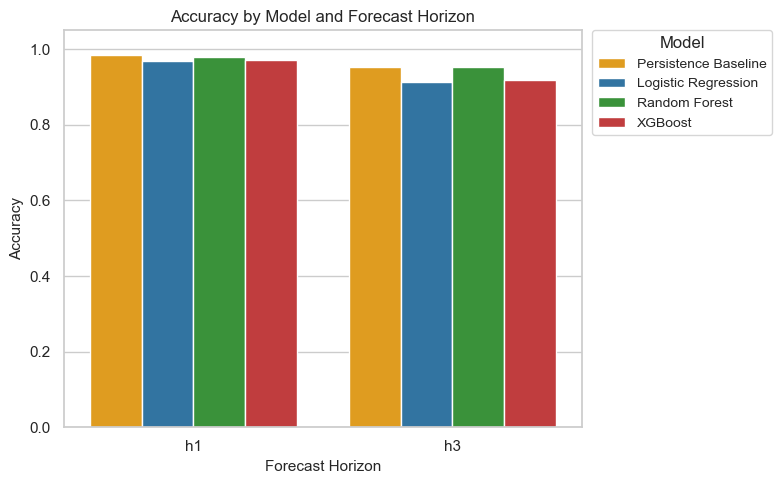

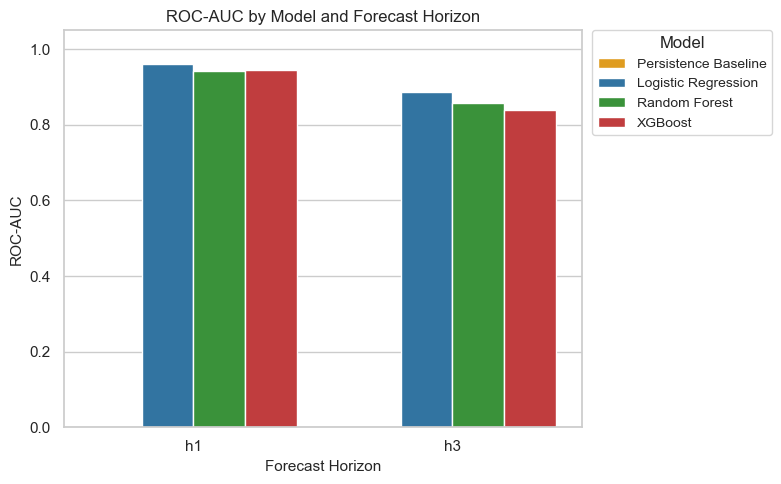

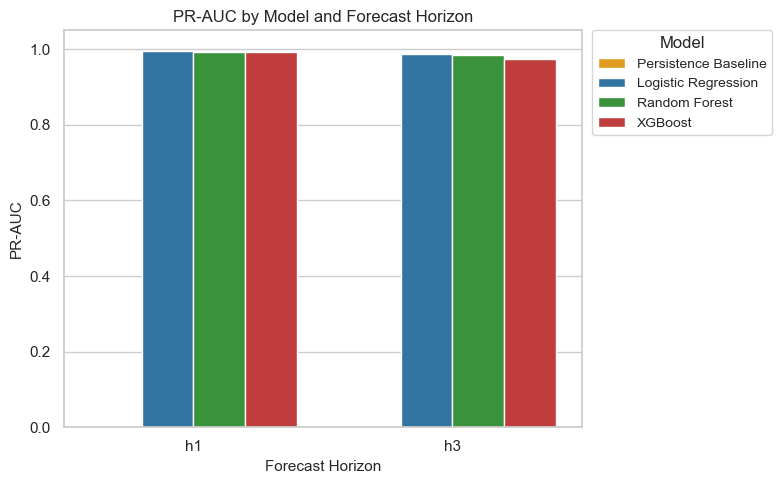

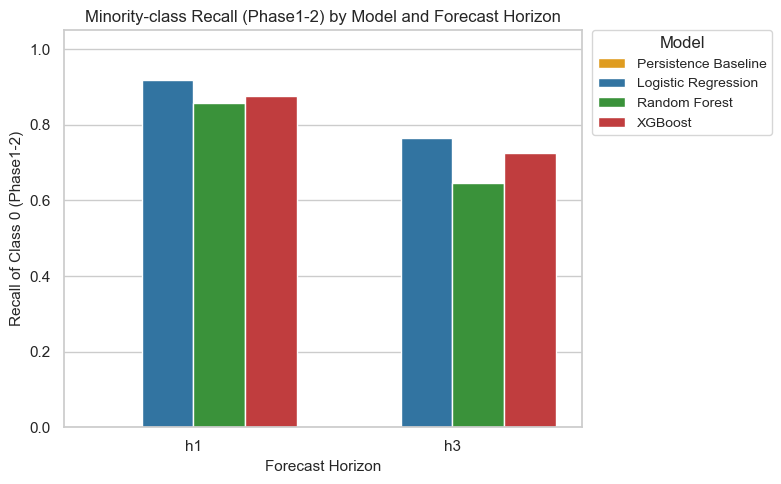

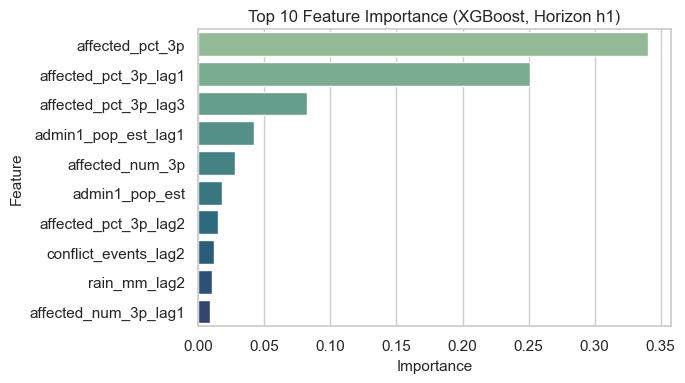


Summary and figures saved in: data clean\model_results


In [7]:
# ======================================================
# evaluation_visuals.py
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ------------------------------------------------------
# Paths
# ------------------------------------------------------
RESULTS_DIR = Path("data clean/model_results")
BASELINE_PATH = Path("data clean") / "baseline_persistence_results.csv"
OUT_DIR = RESULTS_DIR
OUT_DIR.mkdir(exist_ok=True, parents=True)

# ------------------------------------------------------
# 1. Load ML model results (LogReg / RF / XGB)
# ------------------------------------------------------
pattern_map = {
    "logreg": "Logistic Regression",
    "rf": "Random Forest",
    "xgb": "XGBoost"
}

ml_frames = []
for path in RESULTS_DIR.glob("*_summary.csv"):
    fname = path.name.lower()
    model_name = None
    for key, label in pattern_map.items():
        if key in fname:
            model_name = label
            break
    if model_name is None:
        continue

    df = pd.read_csv(path)
    df["model"] = model_name

    rename_map = {
        "test_accuracy": "accuracy",
        "test_roc_auc": "roc_auc",
        "test_pr_auc": "pr_auc",
        "minority_recall": "minority_recall"
    }
    df = df.rename(columns=rename_map)

    for col in ["accuracy", "roc_auc", "pr_auc", "minority_recall"]:
        if col not in df.columns:
            df[col] = np.nan

    keep_cols = ["model", "horizon", "accuracy", "roc_auc", "pr_auc", "minority_recall"]
    df = df[keep_cols]
    ml_frames.append(df)

if not ml_frames:
    raise FileNotFoundError("No *_summary.csv found in 'model_results'. Please run your model scripts first.")

df_ml = pd.concat(ml_frames, ignore_index=True)
df_ml["horizon"] = df_ml["horizon"].astype(str)

# ------------------------------------------------------
# 2. Load persistence baseline (trainable subset only)
# ------------------------------------------------------
if BASELINE_PATH.exists():
    df_base = pd.read_csv(BASELINE_PATH)

    df_base = df_base[df_base["dataset"].str.contains("Trainable", case=False, na=False)]

    df_base["model"] = "Persistence Baseline"
    df_base["roc_auc"] = np.nan
    df_base["pr_auc"] = np.nan
    df_base["minority_recall"] = np.nan

    df_base = df_base[["model", "horizon", "accuracy", "roc_auc", "pr_auc", "minority_recall"]]
else:
    print("Warning: baseline_persistence_results.csv not found. Skipping baseline.")
    df_base = pd.DataFrame(columns=["model", "horizon", "accuracy", "roc_auc", "pr_auc", "minority_recall"])

# ------------------------------------------------------
# 3. Combine all results
# ------------------------------------------------------
df_all = pd.concat([df_ml, df_base], ignore_index=True)
df_all = df_all.sort_values(["model", "horizon"]).reset_index(drop=True)

print("\nCombined evaluation results:")
display(df_all)

df_all["horizon"] = df_all["horizon"].str.lower().str.strip()
df_all["horizon"] = df_all["horizon"].replace({"h01": "h1", "h03": "h3"})
df_all = df_all[df_all["horizon"].isin(["h1", "h3"])]

# optional: enforce plotting order
df_all["horizon"] = pd.Categorical(df_all["horizon"], categories=["h1", "h3"], ordered=True)

# ------------------------------------------------------
# 4. Visualization setup
# ------------------------------------------------------
sns.set(style="whitegrid", font_scale=1.0)
plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

# Fixed order & custom colors
palette_order = ["Persistence Baseline", "Logistic Regression", "Random Forest", "XGBoost"]
custom_colors = ["#FFA500", "#1F77B4", "#2CA02C", "#D62728"]
palette = dict(zip(palette_order, custom_colors))

# ------------------------------------------------------
# 5. Accuracy comparison (h1/h3 x-axis)
# ------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_all,
    x="horizon",
    y="accuracy",
    hue="model",
    hue_order=palette_order,
    palette=palette
)
plt.title("Accuracy by Model and Forecast Horizon")
plt.ylabel("Accuracy")
plt.xlabel("Forecast Horizon")
plt.ylim(0, 1.05)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_accuracy_horizon_model.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------
# 6a. ROC-AUC comparison (same layout)
# ------------------------------------------------------
df_auc = df_all[df_all["model"] != "Persistence Baseline"].copy()
if not df_auc["roc_auc"].isna().all():
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df_auc,
        x="horizon",
        y="roc_auc",
        hue="model",
        hue_order=palette_order,
        palette=palette
    )
    plt.title("ROC-AUC by Model and Forecast Horizon")
    plt.ylabel("ROC-AUC")
    plt.xlabel("Forecast Horizon")
    plt.ylim(0, 1.05)
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_auc_horizon_model.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("ROC-AUC not available; skipping ROC-AUC plot.")

# ------------------------------------------------------
# 6b. PR-AUC comparison (same layout)
# ------------------------------------------------------
df_prauc = df_all[df_all["model"] != "Persistence Baseline"].copy()
if "pr_auc" in df_prauc.columns and not df_prauc["pr_auc"].isna().all():
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df_prauc,
        x="horizon",
        y="pr_auc",
        hue="model",
        hue_order=palette_order,
        palette=palette
    )
    plt.title("PR-AUC by Model and Forecast Horizon")
    plt.ylabel("PR-AUC")
    plt.xlabel("Forecast Horizon")
    plt.ylim(0, 1.05)
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_prauc_horizon_model.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("PR-AUC not available; skipping PR-AUC plot.")

# ------------------------------------------------------
# 7. Minority-class recall comparison (same layout)
# ------------------------------------------------------
if "minority_recall" in df_auc.columns and not df_auc["minority_recall"].isna().all():
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df_auc,
        x="horizon",
        y="minority_recall",
        hue="model",
        hue_order=palette_order,
        palette=palette
    )
    plt.title("Minority-class Recall (Phase1-2) by Model and Forecast Horizon")
    plt.ylabel("Recall of Class 0 (Phase1-2)")
    plt.xlabel("Forecast Horizon")
    plt.ylim(0, 1.05)
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_minority_recall_horizon_model.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Minority recall not available; skipping minority recall plot.")

# ------------------------------------------------------
# 8. Feature importance (XGBoost h1)
# ------------------------------------------------------
xgb_imp_path = OUT_DIR / "xgb_h1_importance.csv"
if not xgb_imp_path.exists():
    xgb_imp_path = OUT_DIR / "xgb_h1_CV_importance.csv"

if xgb_imp_path.exists():
    xgb_imp = pd.read_csv(xgb_imp_path).sort_values("importance", ascending=False).head(10)
    plt.figure(figsize=(7, 4))
    sns.barplot(data=xgb_imp, x="importance", y="feature", palette="crest")
    plt.title("Top 10 Feature Importance (XGBoost, Horizon h1)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_xgb_feature_importance.png", dpi=300)
    plt.show()
else:
    print("Feature importance file not found; skipping XGBoost feature plot.")

# ------------------------------------------------------
# 9. Save merged results
# ------------------------------------------------------
df_all.to_csv(OUT_DIR / "combined_model_summary.csv", index=False, encoding="utf-8-sig")
print("\nSummary and figures saved in:", OUT_DIR)


Loading model results...

Combined Results:
               model horizon  accuracy  roc_auc   pr_auc  minority_recall
Persistence Baseline      h1  0.984127      NaN      NaN              NaN
Persistence Baseline      h3  0.952381      NaN      NaN              NaN
 Logistic Regression      h1  0.968254 0.960325 0.995269         0.918367
 Logistic Regression      h3  0.913420 0.886843 0.987057         0.764706
       Random Forest      h1  0.979798 0.942610 0.992677         0.857143
       Random Forest      h3  0.953824 0.856912 0.983795         0.647059
             XGBoost      h1  0.971140 0.945668 0.991989         0.877551
             XGBoost      h3  0.919192 0.840236 0.975390         0.725490

Figures will be saved to: data clean\model_results\comparison_figs


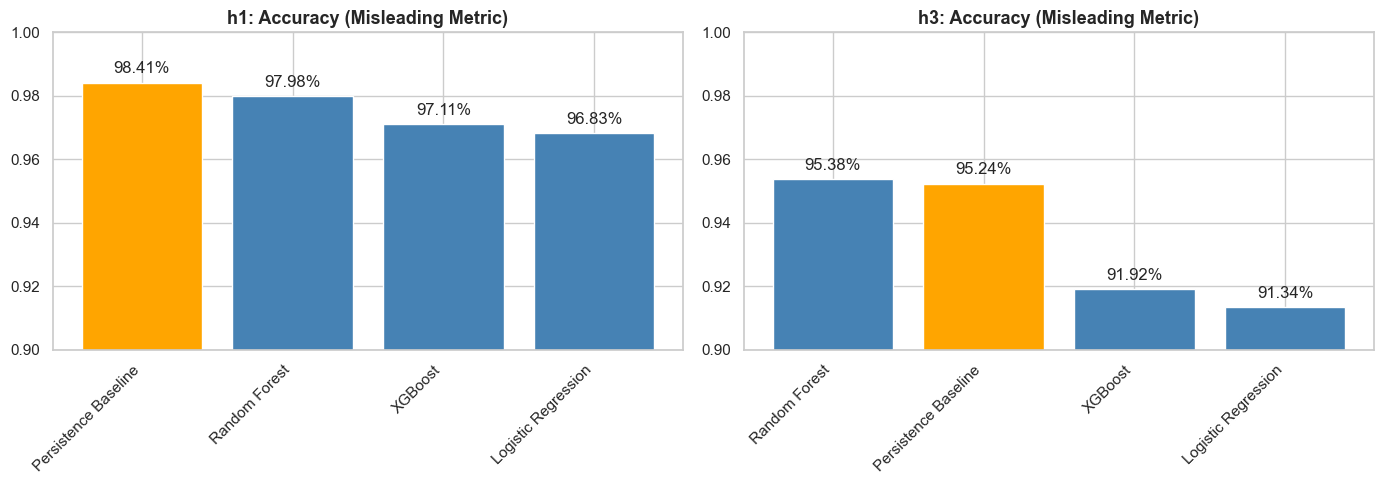

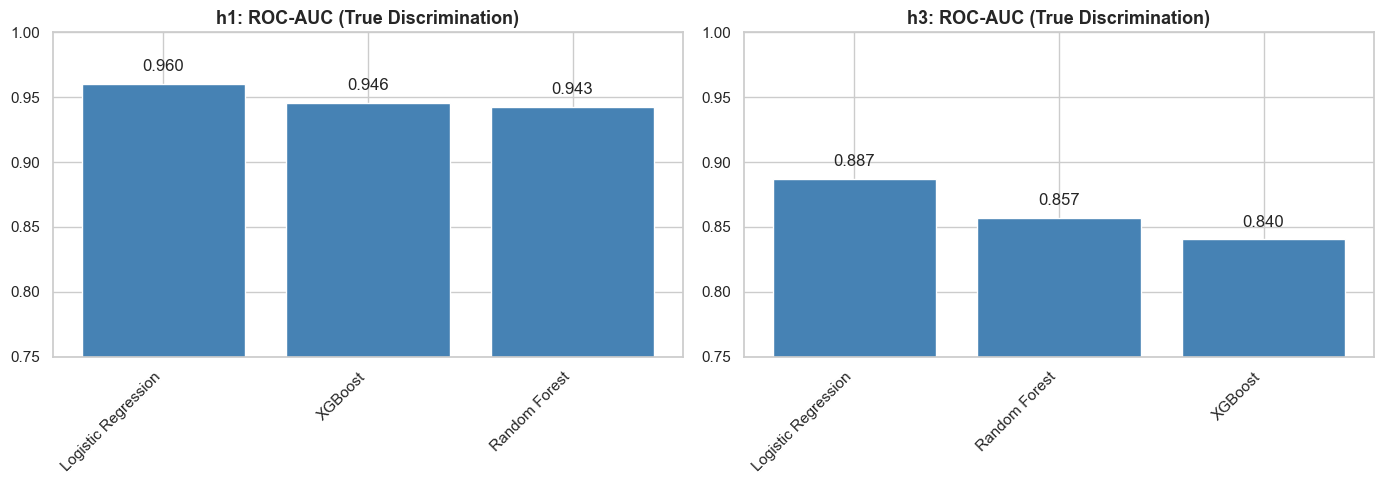

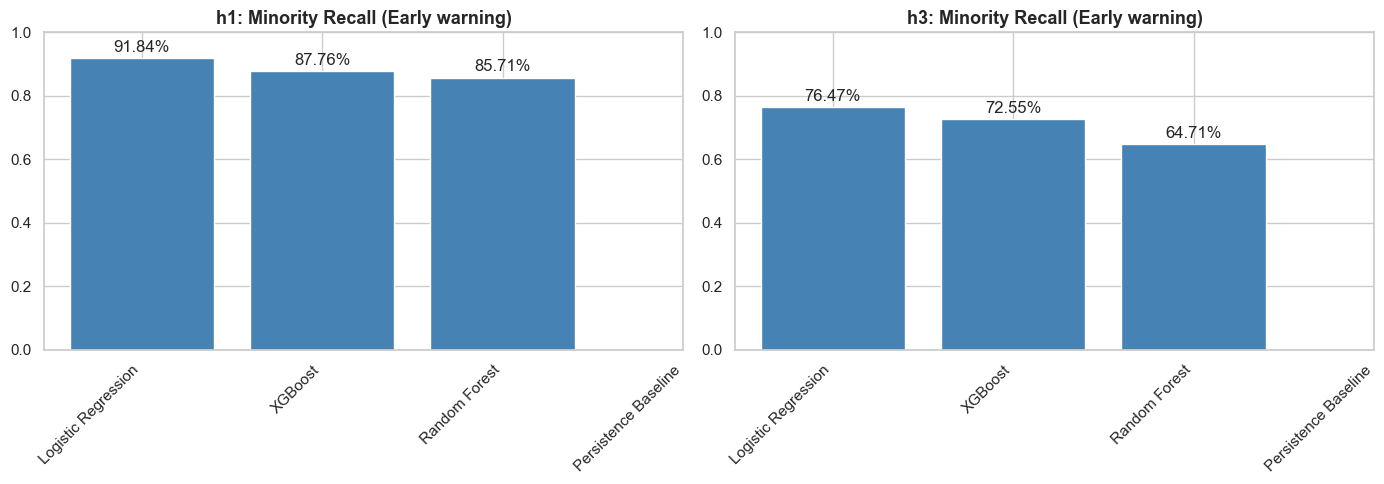

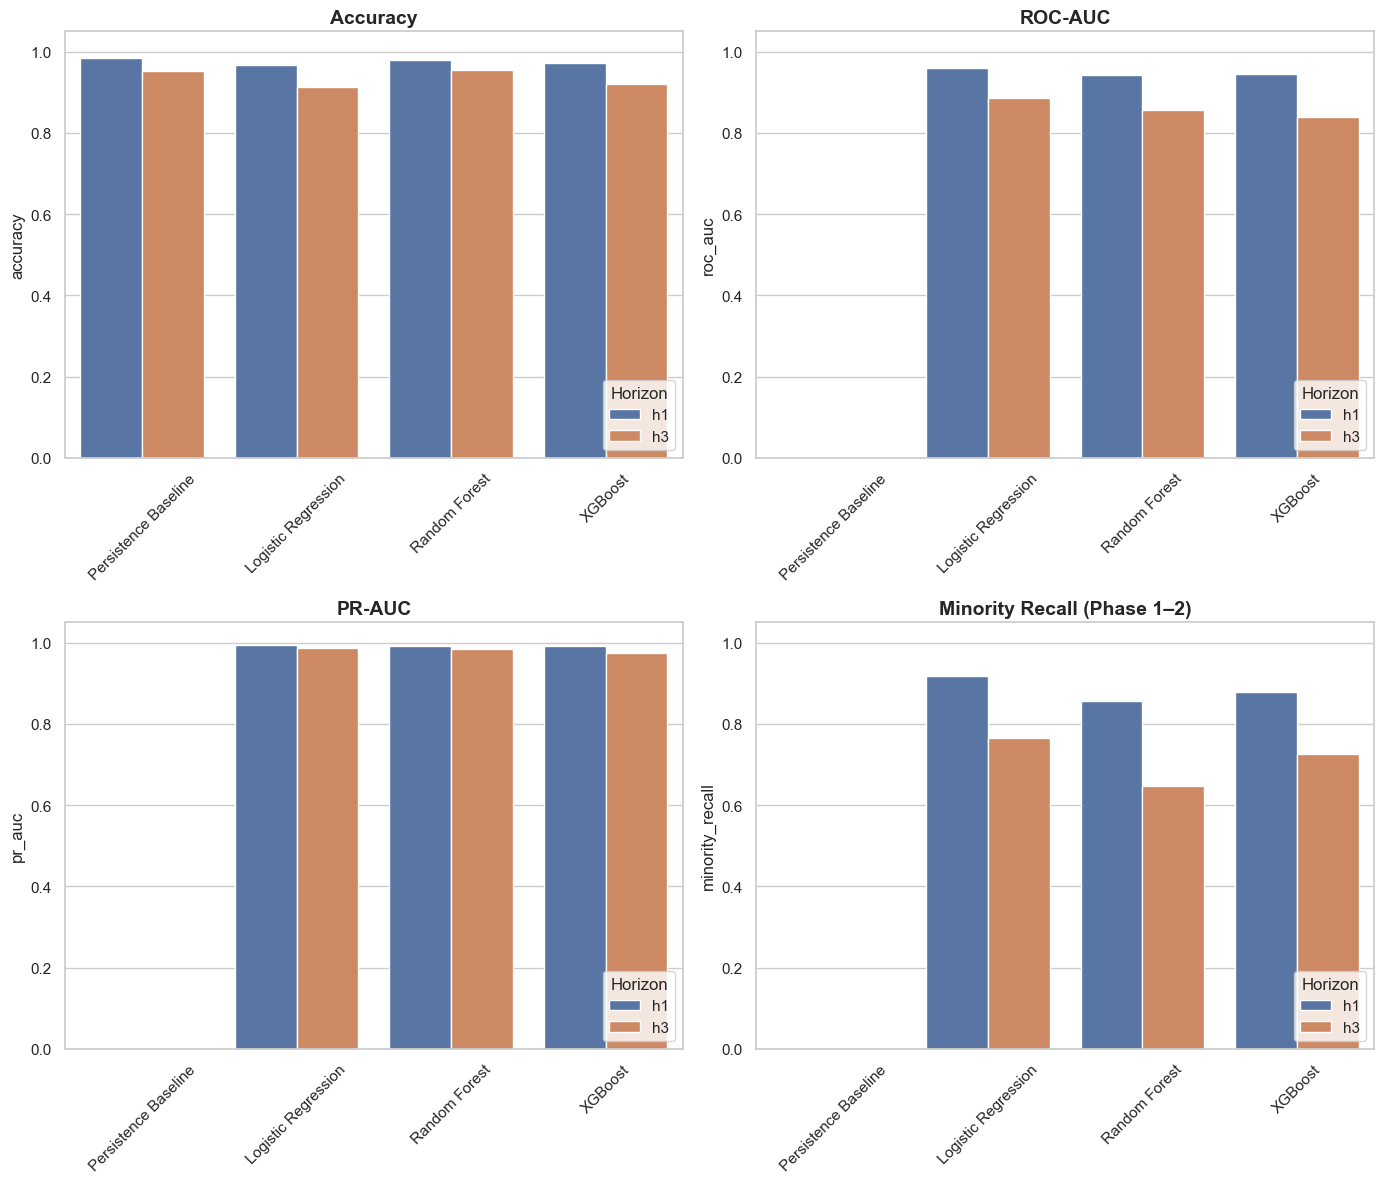


Saved:combined_model_summary.csv


In [8]:
# ======================================================
# evaluation_comparison_visuals.py
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ======================================================
# Configuration
# ======================================================
DATA_CLEAN = Path("data clean")
RESULTS_DIR = DATA_CLEAN / "model_results"
BASELINE_PATH = DATA_CLEAN / "baseline_persistence_results.csv"
OUT_DIR = RESULTS_DIR / "comparison_figs"
OUT_DIR.mkdir(exist_ok=True, parents=True)

sns.set(style="whitegrid", font_scale=1.0)

# ======================================================
# 1. Load ML results
# ======================================================
print("Loading model results...")

ml_results = []
model_mapping = {
    "logreg": "Logistic Regression",
    "rf": "Random Forest",
    "xgb": "XGBoost",
}

for m in ["logreg", "rf", "xgb"]:
    for h in ["h1", "h3"]:
        fp = RESULTS_DIR / f"{m}_{h}_summary.csv"
        if fp.exists():
            df = pd.read_csv(fp)
            df["model"] = model_mapping[m]
            ml_results.append(df)

if len(ml_results) == 0:
    raise RuntimeError("No ML summary CSVs found in model_results.")

df_ml = pd.concat(ml_results, ignore_index=True)

# unify column names
rename_map = {
    "test_accuracy": "accuracy",
    "test_roc_auc": "roc_auc",
    "test_pr_auc": "pr_auc",
}
df_ml = df_ml.rename(columns=rename_map)

# ensure required columns
for col in ["accuracy", "roc_auc", "pr_auc", "minority_recall"]:
    if col not in df_ml.columns:
        df_ml[col] = np.nan

df_ml = df_ml[["model", "horizon", "accuracy", "roc_auc", "pr_auc", "minority_recall"]]

# ======================================================
# 2. Load baseline
# ======================================================
if not BASELINE_PATH.exists():
    raise RuntimeError("baseline_persistence_results.csv not found.")

df_base = pd.read_csv(BASELINE_PATH)
df_base = df_base[df_base["dataset"].str.contains("Trainable", case=False)]

df_base["model"] = "Persistence Baseline"

# persistence baseline has no AUC → fill NaN
df_base["roc_auc"] = np.nan
df_base["pr_auc"] = np.nan

# minority recall for persistence baseline is invalid → set NaN
df_base["minority_recall"] = np.nan

df_base = df_base[["model", "horizon", "accuracy", "roc_auc", "pr_auc", "minority_recall"]]

# ======================================================
# 3. Merge ML + baseline
# ======================================================
df_all = pd.concat([df_base, df_ml], ignore_index=True)

print("\nCombined Results:")
print(df_all.to_string(index=False))
print("\nFigures will be saved to:", OUT_DIR)

# ======================================================
# 4. FIGURE 1 — Accuracy (Misleading)
# ======================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, horizon in enumerate(["h1", "h3"]):
    subset = df_all[df_all["horizon"] == horizon].sort_values("accuracy", ascending=False)
    ax = axes[idx]

    colors = ["orange" if m == "Persistence Baseline" else "steelblue"
              for m in subset["model"]]

    bars = ax.bar(range(len(subset)), subset["accuracy"], color=colors)
    ax.set_xticks(range(len(subset)))
    ax.set_xticklabels(subset["model"], rotation=45, ha="right")
    ax.set_title(f"{horizon}: Accuracy (Misleading Metric)", fontsize=13, fontweight="bold")
    ax.set_ylim(0.90, 1.0)

    for bar, val in zip(bars, subset["accuracy"]):
        ax.text(bar.get_x() + bar.get_width()/2., val + 0.002,
                f"{val:.2%}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(OUT_DIR / "fig1_accuracy_misleading.png", dpi=300)
plt.show()

# ======================================================
# 5. ROC-AUC (ML only)
# ======================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, horizon in enumerate(["h1", "h3"]):
    subset = df_all[(df_all["horizon"] == horizon) &
                    (df_all["model"] != "Persistence Baseline")]

    subset = subset.sort_values("roc_auc", ascending=False)
    ax = axes[idx]

    bars = ax.bar(range(len(subset)), subset["roc_auc"], color="steelblue")
    ax.set_xticks(range(len(subset)))
    ax.set_xticklabels(subset["model"], rotation=45, ha="right")
    ax.set_title(f"{horizon}: ROC-AUC (True Discrimination)", fontsize=13, fontweight="bold")
    ax.set_ylim(0.75, 1.0)

    for bar, val in zip(bars, subset["roc_auc"]):
        ax.text(bar.get_x() + bar.get_width()/2., val + 0.01,
                f"{val:.3f}", ha="center")

plt.tight_layout()
plt.savefig(OUT_DIR / "fig2_auc_comparison.png", dpi=300)
plt.show()

# ======================================================
# 6. Minority Recall (Early Warning)
# ======================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, horizon in enumerate(["h1", "h3"]):
    subset = df_all[df_all["horizon"] == horizon].sort_values("minority_recall", ascending=False)
    ax = axes[idx]

    colors = ["orange" if m == "Persistence Baseline" else "steelblue"
              for m in subset["model"]]

    bars = ax.bar(range(len(subset)), subset["minority_recall"], color=colors)
    ax.set_xticks(range(len(subset)))
    ax.set_xticklabels(subset["model"], rotation=45, ha="right")
    ax.set_title(f"{horizon}: Minority Recall (Early warning)", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.0)

    for bar, val in zip(bars, subset["minority_recall"]):
        if not pd.isna(val):
            ax.text(bar.get_x() + bar.get_width()/2., val + 0.02,
                    f"{val:.2%}", ha="center")

plt.tight_layout()
plt.savefig(OUT_DIR / "11. minority_recall.png", dpi=300)
plt.show()

# ======================================================
# 7. COMPREHENSIVE 2x2 COMPARISON FIGURE (FIXED)
# ======================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
metrics = [
    ("accuracy", "Accuracy"),
    ("roc_auc", "ROC-AUC"),
    ("pr_auc", "PR-AUC"),
    ("minority_recall", "Minority Recall (Phase 1–2)")
]

for ax, (metric, title) in zip(axes.flatten(), metrics):

    sns.barplot(
        data=df_all,
        x="model",
        y=metric,
        hue="horizon",
        palette={"h1": "#4C72B0", "h3": "#DD8452"},
        ax=ax
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Horizon", loc="lower right")

plt.tight_layout()
plt.savefig(OUT_DIR / "10. fig4_comprehensive_comparison.png", dpi=300)
plt.show()


# ======================================================
# 8. Export combined summary
# ======================================================
df_all.to_csv(OUT_DIR / "combined_model_summary.csv",
              index=False, encoding="utf-8-sig")

print("\nSaved:combined_model_summary.csv")



===== Running SHAP Analysis for H1 =====
Model trained and saved: data clean\model_results\xgb_h1_safe_model.json
TreeExplainer failed (ValueError: could not convert string to float: '[5E-1]') → using PermutationExplainer...


PermutationExplainer explainer: 694it [03:18,  3.34it/s]                                                               


Saved SHAP values: data clean\model_results\shap\shap_values_h1.csv


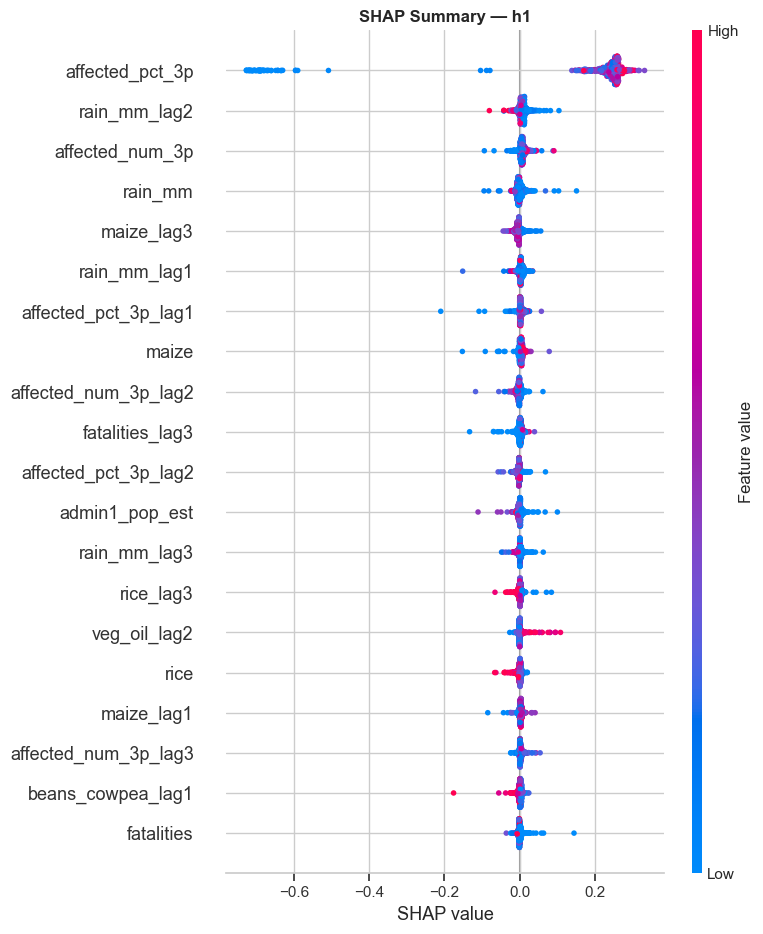

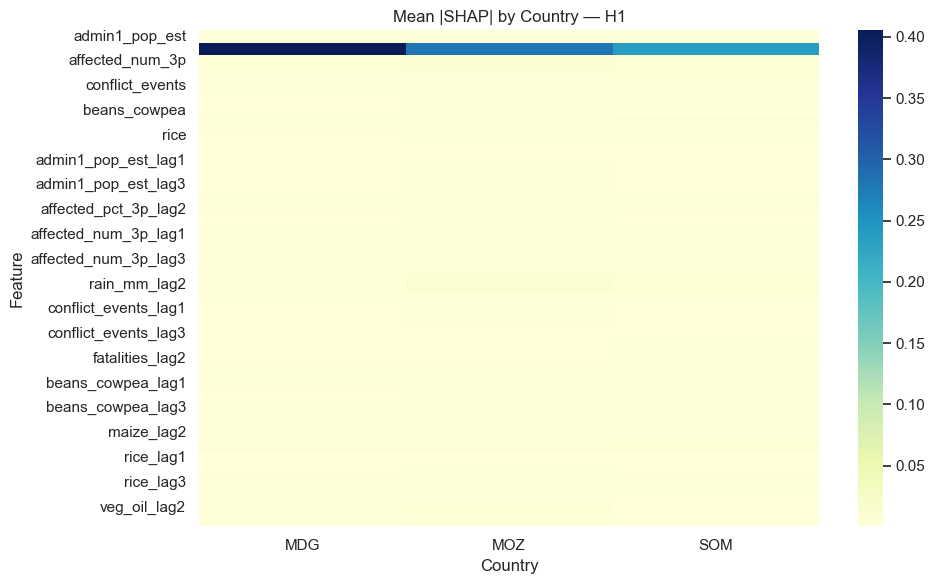

,Feature,MeanSHAP,MeanAbsSHAP
1,affected_pct_3p,0.182191,0.271063
20,rain_mm_lag2,0.007235,0.009665
2,affected_num_3p,0.006457,0.008516
3,rain_mm,-0.000146,0.006658
33,maize_lag3,-0.002970,0.006551
19,rain_mm_lag1,0.002780,0.005236
13,affected_pct_3p_lag1,0.002226,0.004968
7,maize,0.002536,0.004864
17,affected_num_3p_lag2,-0.002092,0.004711
27,fatalities_lag3,0.000102,0.004438


Top-10 features saved: data clean\model_results\shap\top10_features_h1.csv

Summarizing SHAP by country (h1)...
Top-5 features per country saved: data clean\model_results\shap\top5_features_by_country_h1.csv


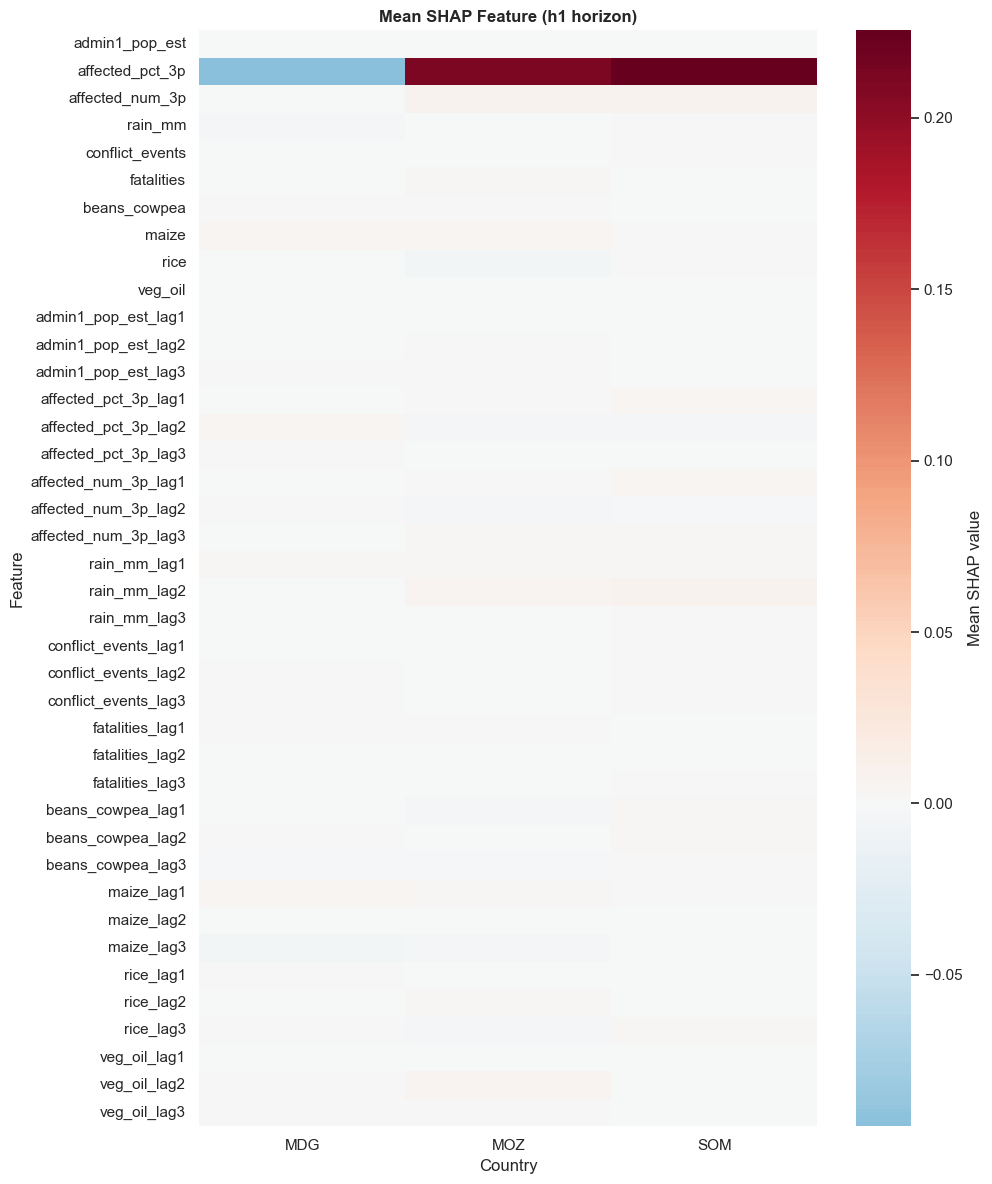

Saved summary heatmap: data clean\model_results\shap\shap_country_summary_h1.png


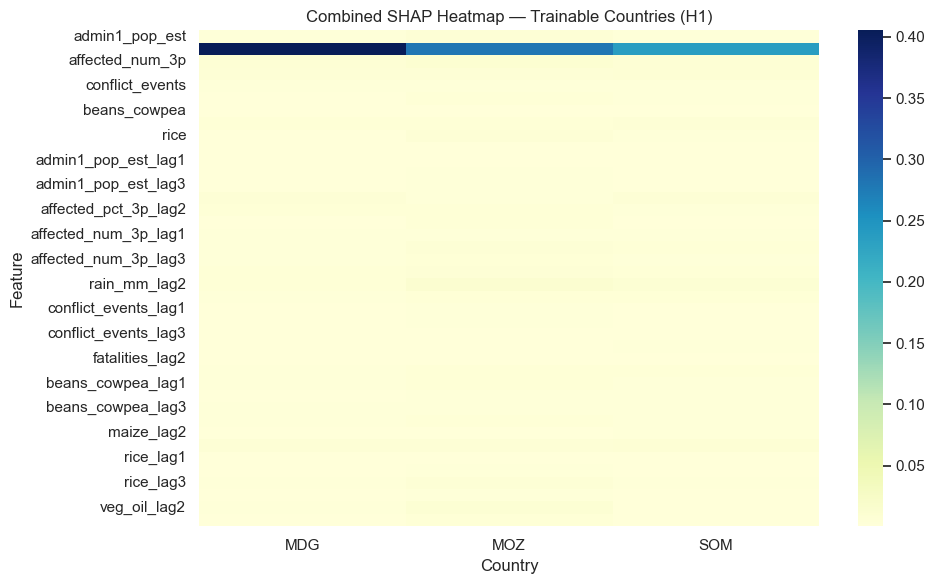

Saved combined SHAP heatmap: data clean\model_results\shap\shap_heatmap_allcountries_h1.png

===== Running SHAP Analysis for H3 =====
Model trained and saved: data clean\model_results\xgb_h3_safe_model.json
TreeExplainer failed (ValueError: could not convert string to float: '[5E-1]') → using PermutationExplainer...


PermutationExplainer explainer: 694it [02:41,  4.00it/s]                                                               


Saved SHAP values: data clean\model_results\shap\shap_values_h3.csv


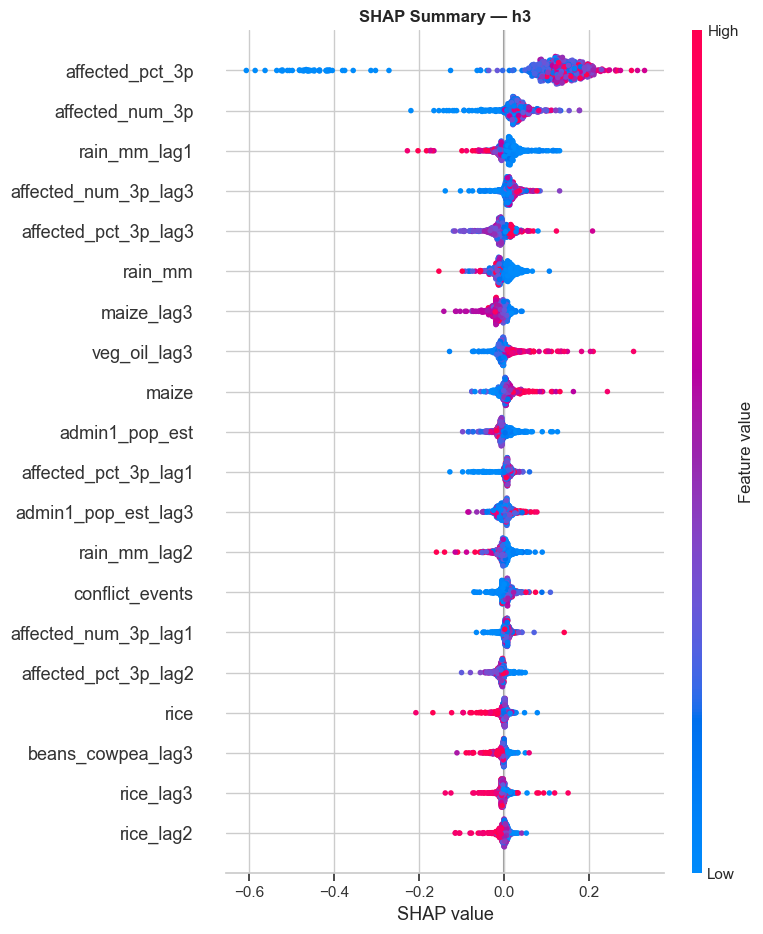

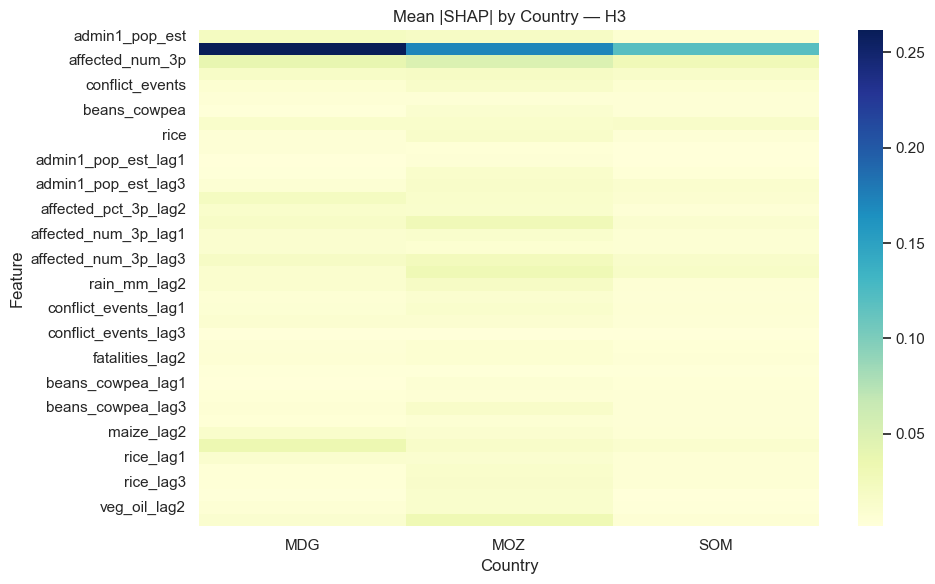

,Feature,MeanSHAP,MeanAbsSHAP
1,affected_pct_3p,0.100038,0.154509
2,affected_num_3p,0.028134,0.036869
19,rain_mm_lag1,0.007573,0.020633
18,affected_num_3p_lag3,0.014604,0.018363
15,affected_pct_3p_lag3,-0.003864,0.017041
3,rain_mm,0.000117,0.016579
33,maize_lag3,-0.009761,0.015391
39,veg_oil_lag3,0.003994,0.014821
7,maize,0.007525,0.014151
0,admin1_pop_est,0.000113,0.013403


Top-10 features saved: data clean\model_results\shap\top10_features_h3.csv

Summarizing SHAP by country (h3)...
Top-5 features per country saved: data clean\model_results\shap\top5_features_by_country_h3.csv


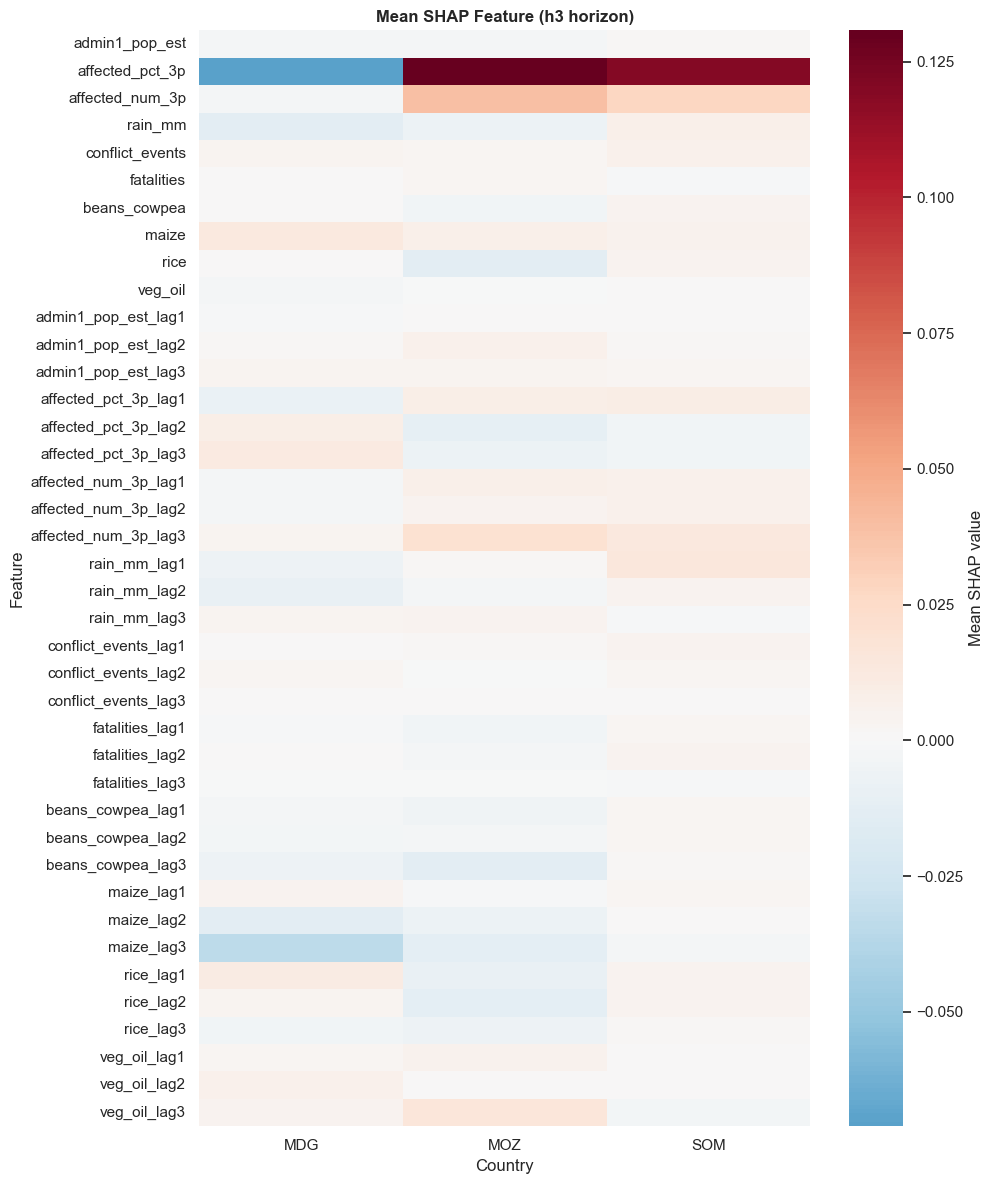

Saved summary heatmap: data clean\model_results\shap\shap_country_summary_h3.png


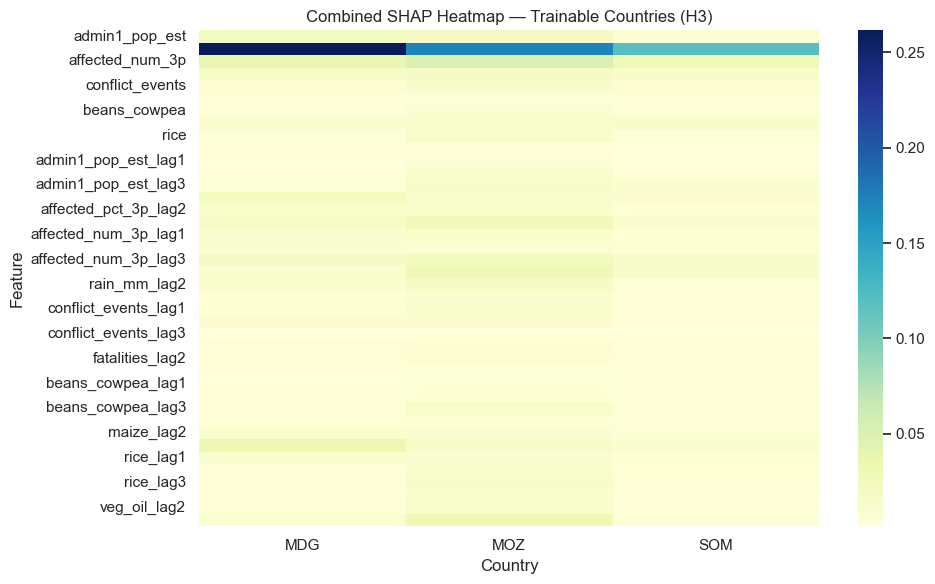

Saved combined SHAP heatmap: data clean\model_results\shap\shap_heatmap_allcountries_h3.png

All SHAP analyses complete. Results saved in: data clean\model_results\shap


In [9]:
# ======================================================
# xgb_shap_full_pipeline.py
# ======================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import xgboost as xgb
from sklearn.impute import SimpleImputer
from IPython.display import display

# ------------------------------------------------------
# Configuration
# ------------------------------------------------------
DATA_CLEAN = Path("data clean")
RESULTS_DIR = DATA_CLEAN / "model_results"
SHAP_DIR = RESULTS_DIR / "shap"
SHAP_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_PATH = DATA_CLEAN / "train_features_2017_2025_lagged.csv"

TRAIN_RATIO = 0.8
TRAINABLE_COUNTRIES = ["MDG", "MOZ", "SOM"]
RANDOM_STATE = 42


# ------------------------------------------------------
# Run SHAP analysis for one horizon
# ------------------------------------------------------
def run_shap_for_horizon(TARGET_HORIZON: str):
    print(f"\n===== Running SHAP Analysis for {TARGET_HORIZON.upper()} =====")

    df = pd.read_csv(TRAIN_PATH)
    df["year_month"] = pd.to_datetime(df["year_month"])

    target_col = f"phase3plus_binary_20pct_{TARGET_HORIZON}"
    exclude_cols = [
        "country", "admin1", "admin1_key", "year_month",
        "phase3plus_binary_20pct", "phase3plus_binary_20pct_h1",
        "phase3plus_binary_20pct_h3"
    ]
    feature_cols = [c for c in df.columns if c not in exclude_cols]

    # Filter to trainable countries and valid targets
    df = df.dropna(subset=[target_col])
    df = df[df["country"].isin(TRAINABLE_COUNTRIES)].copy()
    df = df.sort_values("year_month").reset_index(drop=True)

    # Time-based split
    n_total = len(df)
    n_train = int(n_total * TRAIN_RATIO)
    train_df, test_df = df.iloc[:n_train], df.iloc[n_train:]

    X_train_raw, X_test_raw = train_df[feature_cols], test_df[feature_cols]
    y_train = train_df[target_col].astype(float)

    # Impute missing values
    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train_raw)
    X_test = imputer.transform(X_test_raw)

    # Load or train XGBoost
    model_path = RESULTS_DIR / f"xgb_{TARGET_HORIZON}_safe_model.json"
    model = xgb.XGBClassifier()
    if model_path.exists():
        model.load_model(model_path)
        print(f"Loaded existing model: {model_path}")
    else:
        n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
        spw = n_neg / n_pos if n_pos > 0 else 1.0
        model = xgb.XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss", use_label_encoder=False,
            scale_pos_weight=spw, random_state=RANDOM_STATE
        )
        model.fit(X_train, y_train)
        model.save_model(model_path)
        print(f"Model trained and saved: {model_path}")

   # Compute SHAP values (TreeExplainer → fallback to PermutationExplainer)
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        shap_array = np.array(shap_values)
        print("Used TreeExplainer")
    except Exception as e:
        print(f"TreeExplainer failed ({type(e).__name__}: {e}) → using PermutationExplainer...")
        explainer = shap.Explainer(model.predict, X_train_raw, feature_names=feature_cols)
        shap_values = explainer(X_test_raw)
        shap_array = shap_values.values


    # Save SHAP dataframe
    shap_df = pd.DataFrame(shap_array, columns=feature_cols)
    shap_df["country"] = test_df["country"].reset_index(drop=True)
    shap_file = SHAP_DIR / f"shap_values_{TARGET_HORIZON}.csv"
    shap_df.to_csv(shap_file, index=False)
    print(f"Saved SHAP values: {shap_file}")

    # SHAP summary plot
    shap.summary_plot(shap_array, X_test_raw, feature_names=feature_cols, max_display=20, show=False)
    plt.title(f"SHAP Summary — {TARGET_HORIZON}", fontweight='bold')
    plt.xlabel("SHAP value")
    plt.tight_layout()
    plt.savefig(SHAP_DIR / f"shap_summary_{TARGET_HORIZON}.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Per-country mean |SHAP| heatmap
    mean_abs = shap_df.groupby("country")[feature_cols].apply(lambda x: np.abs(x).mean())
    plt.figure(figsize=(10, 6))
    sns.heatmap(mean_abs.T, cmap="YlGnBu", annot=False)
    plt.title(f"Mean |SHAP| by Country — {TARGET_HORIZON.upper()}")
    plt.xlabel("Country")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(SHAP_DIR / f"shap_heatmap_{TARGET_HORIZON}.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Global Top-10 features
    top10 = pd.DataFrame({
        "Feature": feature_cols,
        "MeanSHAP": shap_array.mean(axis=0),  # retain sign → direction
        "MeanAbsSHAP": np.abs(shap_array).mean(axis=0)  # absolute importance
    }).sort_values("MeanAbsSHAP", ascending=False).head(10)
    
    top10_file = SHAP_DIR / f"top10_features_{TARGET_HORIZON}.csv"
    top10.to_csv(top10_file, index=False)
    display(top10)
    print(f"Top-10 features saved: {top10_file}")

    return shap_file

# ------------------------------------------------------
# Summarize SHAP by country
# ------------------------------------------------------
def summarize_country_shap(shap_file: Path, horizon: str):
    print(f"\nSummarizing SHAP by country ({horizon})...")

    shap_df = pd.read_csv(shap_file)
    if "country" not in shap_df.columns:
        raise ValueError("Expected 'country' column in SHAP CSV.")

    # Compute mean SHAP values per country
    country_mean = shap_df.groupby("country").mean(numeric_only=True).T

    mean_abs = shap_df.groupby("country")[country_mean.index].apply(lambda x: np.abs(x).mean())
    country_top5 = mean_abs.apply(lambda x: x.sort_values(ascending=False).head(5), axis=1)
    top5_file = SHAP_DIR / f"top5_features_by_country_{horizon}.csv"
    country_top5.to_csv(top5_file)
    print(f"Top-5 features per country saved: {top5_file}")
    
    out_csv = SHAP_DIR / f"shap_country_summary_{horizon}.csv"
    out_fig = SHAP_DIR / f"shap_country_summary_{horizon}.png"
    country_mean.to_csv(out_csv, encoding="utf-8-sig")

    plt.figure(figsize=(10, max(5, len(country_mean) * 0.3)))
    sns.heatmap(country_mean, cmap="RdBu_r", center=0, annot=False,
                cbar_kws={"label": "Mean SHAP value"})
    plt.title(f"Mean SHAP Feature ({horizon} horizon)", fontweight='bold')
    plt.xlabel("Country")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(out_fig, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved summary heatmap: {out_fig}")


# ------------------------------------------------------
# Supplementary: Combined SHAP Heatmap (cross-country)
# ------------------------------------------------------
def visualize_all_countries_shap(horizon: str):
    shap_file = SHAP_DIR / f"shap_values_{horizon}.csv"
    df = pd.read_csv(shap_file)
    df = df[df["country"].isin(TRAINABLE_COUNTRIES)]

    feature_cols = [c for c in df.columns if c not in ["country"]]
    mean_abs = df.groupby("country")[feature_cols].apply(lambda x: np.abs(x).mean())

    plt.figure(figsize=(10, 6))
    sns.heatmap(mean_abs.T, cmap="YlGnBu", annot=False)
    plt.title(f"Combined SHAP Heatmap — Trainable Countries ({horizon.upper()})")
    plt.xlabel("Country")
    plt.ylabel("Feature")
    plt.tight_layout()
    out_path = SHAP_DIR / f"shap_heatmap_allcountries_{horizon}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved combined SHAP heatmap: {out_path}")


# ------------------------------------------------------
# Main execution
# ------------------------------------------------------
for horizon in ["h1", "h3"]:
    shap_csv = run_shap_for_horizon(horizon)
    summarize_country_shap(shap_csv, horizon)
    visualize_all_countries_shap(horizon)

print("\nAll SHAP analyses complete. Results saved in:", SHAP_DIR)
